In [1]:
# Load all shared modules
from Imports import *
from settings import *
from Inputs import *
from Helper import *
from PlotHelper import *


PROJ_LIB = None
PROJ_DATA = None
numpy version: 2.3.5
matplotlib version: 3.10.8
flopy version: 3.10.0


In [2]:
# ============================================================
# EXPORT RUN CONFIGURATION
# Saves config_snapshot.py and run_summary.txt into sim_ws
# so every simulation has a permanent record of its settings.
# ============================================================
save_run_config(sim_ws)


Config snapshot : D:\Users\abolmaal\modelling\Modflow\Testing_6\config_snapshot.py
Run summary     : D:\Users\abolmaal\modelling\Modflow\Testing_6\run_summary.txt


# Great Lakes Basin MODFLOW 6 — Clean, ordered workflow

This notebook is a **reorganized version** of the input-preparation and model-run workflow.
It keeps the core logic from the original notebook, but it puts sections in a cleaner order,
removes most ad-hoc debugging cells, and adds clearer section comments so it is easier to
rerun from top to bottom.

## Recommended execution order
Run the notebook **sequentially** from top to bottom.  
If you change `id2d` / `idomain`, rerun all downstream sections that depend on the active domain:
- recharge
- GHB
- DRN
- plotting
- model build/run


## 3) Build template grid and initial IDOMAIN

This creates the model template raster from the boundary polygon and rasterizes the initial active domain.
At this stage, the domain is only the first-pass rasterized basin footprint.


In [3]:
make_template_from_boundary(boundary_shp, template_tif, CELL)
rasterize_idomain(boundary_shp, template_tif, idomain_tif, burn_value=1, all_touched=False)
assert_match_template_no_crs(idomain_tif, template_tif, "IDOMAIN")

Could not delete locked file: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174\idomain_1000m_epsg3174.tif
IDOMAIN matches template in shape and transform.


In [4]:
id2d, _ = read_band1(idomain_tif, dtype="int32")
id2d = (id2d > 0).astype(np.int32)
print("Active cells:", int(np.count_nonzero(id2d)))

with rio.open(template_tif) as tmp:
    print("Template shape:", (tmp.height, tmp.width), "CRS:", tmp.crs, "transform:", tmp.transform)
    nrow, ncol = tmp.height, tmp.width
    delr = np.full(ncol, tmp.transform.a, dtype=float)
    delc = np.full(nrow, abs(tmp.transform.e), dtype=float)
    xorigin = tmp.bounds.left
    yorigin = tmp.bounds.bottom
    grid_crs = tmp.crs

Active cells: 990144
Template shape: (1319, 1527) CRS: None transform: | 1000.00, 0.00, 298000.00|
| 0.00,-1000.00, 1674000.00|
| 0.00, 0.00, 1.00|


## 4) Build binary drain-presence raster from the drain-elevation raster

This converts the raw drain-elevation raster into a 0/1 presence raster.
Important: only **nonzero, finite** drain-elevation cells are treated as drain presence.


In [5]:
drain_presence_raw = os.path.join(sim_ws, "drain_presence_raw.tif")
# nameInputDrainElev set in config.py

with rio.open(nameInputDrainElev) as src:
    nd = src.nodata
    meta = src.meta.copy()

    meta.update(
        driver="GTiff",
        dtype="uint8",
        count=1,
        nodata=0,
        compress="lzw"
    )

    meta.pop("blockxsize", None)
    meta.pop("blockysize", None)

    with rio.open(drain_presence_raw, "w", **meta) as dst:
        for _, window in src.block_windows(1):
            arr = src.read(1, window=window)

            if nd is not None:
                pres = (
                    np.isfinite(arr) &
                    (arr != nd) &
                    (arr != 0)
                ).astype("uint8")
            else:
                pres = (
                    np.isfinite(arr) &
                    (arr != 0)
                ).astype("uint8")

            dst.write(pres, 1, window=window)

print("Created drain presence raster:", drain_presence_raw)

Created drain presence raster: D:\Users\abolmaal\modelling\Modflow\Testing_6\drain_presence_raw.tif


## 5) Warp all continuous rasters to the common template grid

This aligns all major inputs to the same cell size, extent, and transform as the model template.


In [6]:
# Continuous rasters
warp_raster_to_template(nameInputTop,       template_tif, top_aligned,    Resampling.bilinear, dst_nodata=-9999.0)
warp_raster_to_template(nameInputLayBot,    template_tif, botm_aligned,   Resampling.bilinear, dst_nodata=-9999.0)
warp_raster_to_template(nameInputHorizCond, template_tif, hk_aligned,     Resampling.nearest,  dst_nodata=-9999.0)

# Skip old IBOUND completely
# Ibound_aligned = IBOUND

# Starting heads
warp_raster_to_template(nameInputStrt, template_tif, strt_aligned, Resampling.bilinear, dst_nodata=-9999.0)

# Drains
warp_raster_to_template(nameInputDrainElev, template_tif, drain_elev_aligned, Resampling.nearest, dst_nodata=-9999.0)

warp_raster_to_template(
    drain_presence_raw,
    template_tif,
    drain_frac_aligned,
    Resampling.average,
    dst_nodata=0.0
)

# Bathymetry (Great Lakes lake-floor elevations)
warp_raster_to_template(nameInputBathy, template_tif, bathy_aligned, Resampling.bilinear, dst_nodata=-9999.0)

# Assertions
assert_match_template(top_aligned,         template_tif, "TOP")
assert_match_template(botm_aligned,        template_tif, "BOTM")
assert_match_template(hk_aligned,          template_tif, "HK")
assert_match_template(strt_aligned,        template_tif, "STRT")
assert_match_template(idomain_tif,         template_tif, "IDOMAIN")
assert_match_template(drain_elev_aligned,  template_tif, "DRAIN_ELEV")
assert_match_template(drain_frac_aligned,  template_tif, "DRAIN_FRAC")
assert_match_template(bathy_aligned,         template_tif, "BATHY")

print("All required rasters aligned to template ✅")

All required rasters aligned to template ✅


## 6) Read aligned rasters, sanitize nodata values, and build the core model arrays

This section:
- reads TOP / BOTM / HK / STRT / DRN rasters
- removes bad sentinel values like `-9999`
- builds `id2d` and `idomain`
- maps HK bands to model layers
- deactivates cells with invalid thickness


In [7]:
top2d, top_nd     = read_band1(top_aligned, dtype="float32")
botm_raw, botm_nd = read_all_bands(botm_aligned, dtype="float32")
hk_raw, hk_nd     = read_all_bands(hk_aligned, dtype="float32")

# starting-head raster: interpolated heads
strt2d_raw, strt_nd = read_band1(strt_aligned, dtype="float32")

# ---------------------------------------------------------
# clean continuous rasters
# ---------------------------------------------------------
top2d  = clean_continuous(top2d,    top_nd,  fill=np.nan)
botm3d = clean_continuous(botm_raw, botm_nd, fill=np.nan)
hk_raw = clean_continuous(hk_raw,   hk_nd,   fill=0.0)

# explicit cleanup for bad sentinel values that may survive metadata cleaning
top2d = np.array(top2d, dtype=float)
top2d[~np.isfinite(top2d)] = np.nan
top2d[top2d <= -9000] = np.nan

botm3d = np.array(botm3d, dtype=float)
botm3d[~np.isfinite(botm3d)] = np.nan
botm3d[botm3d <= -9000] = np.nan

hk_raw = np.array(hk_raw, dtype=float)
hk_raw[~np.isfinite(hk_raw)] = 0.0
hk_raw[hk_raw <= -9000] = 0.0

# No lake/land classification in this workflow
# Keep placeholders so later code that expects these variables will still work
mask2d = np.zeros_like(id2d, dtype="float32")
water_mask = np.zeros_like(id2d, dtype=bool)

# keep missing starting heads as NaN so you can fill them later
strt2d_raw = clean_continuous(strt2d_raw, strt_nd, fill=np.nan)
strt2d_raw = np.array(strt2d_raw, dtype=float)
strt2d_raw[~np.isfinite(strt2d_raw)] = np.nan
strt2d_raw[strt2d_raw <= -9000] = np.nan

nlay = botm3d.shape[0]
print("nlay from BOTM bands:", nlay, "| HK bands:", hk_raw.shape[0])

# ---------------------------------------------------------
# read drain rasters
# ---------------------------------------------------------
drain_elev2d, drain_nd = read_band1(drain_elev_aligned, dtype="float32")
drain_frac2d, frac_nd  = read_band1(drain_frac_aligned, dtype="float32")

drain_elev2d = np.array(drain_elev2d, dtype=float)
drain_elev2d[~np.isfinite(drain_elev2d)] = np.nan
if drain_nd is not None:
    drain_elev2d[drain_elev2d == drain_nd] = np.nan
drain_elev2d[drain_elev2d <= -9000] = np.nan

drain_frac2d = np.array(drain_frac2d, dtype=float)
drain_frac2d[~np.isfinite(drain_frac2d)] = 0.0
if frac_nd is not None:
    drain_frac2d[drain_frac2d == frac_nd] = 0.0
drain_frac2d[drain_frac2d <= -9000] = 0.0
drain_frac2d = np.clip(drain_frac2d, 0.0, 1.0)

# keep drains only inside active model cells
drain_frac2d[id2d <= 0] = 0.0
drain_elev2d[id2d <= 0] = np.nan

# ---------------------------------------------------------
# Map HK to layers
# ---------------------------------------------------------
if hk_raw.shape[0] == nlay:
    hk3d = hk_raw.copy()
elif nlay == 1 and hk_raw.shape[0] >= 1:
    hk3d = hk_raw[0:1, :, :].copy()
elif hk_raw.shape[0] == 1 and nlay > 1:
    hk3d = np.repeat(hk_raw, nlay, axis=0)
else:
    hk3d = np.zeros((nlay, nrow, ncol), dtype="float32")
    for k in range(nlay):
        hk3d[k] = hk_raw[min(k, hk_raw.shape[0] - 1)]

# ---------------------------------------------------------
# Inactive -> 0
# ---------------------------------------------------------
top2d[id2d == 0] = 0.0
botm3d[:, id2d == 0] = np.nan
hk3d[:, id2d == 0] = 0.0

# ---------------------------------------------------------
# clamp HK in active
# ---------------------------------------------------------
hk_min, hk_max = 1e-6, 1e4
m = (id2d == 1)
for k in range(nlay):
    hk3d[k, m] = np.clip(hk3d[k, m], hk_min, hk_max)
    hk3d[k, ~m] = 0.0

# ---------------------------------------------------------
# Thickness checks -> deactivate bad cells
# ---------------------------------------------------------
bad = np.zeros_like(id2d, dtype=bool)

thk1 = top2d - botm3d[0]
bad |= (id2d == 1) & (~np.isfinite(thk1) | (thk1 <= 0))

for k in range(1, nlay):
    thk = botm3d[k - 1] - botm3d[k]
    bad |= (id2d == 1) & (~np.isfinite(thk) | (thk <= 0))

print("Bad thickness cells:", int(bad.sum()))

id2d = id2d.copy()
id2d[bad] = 0
idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)
print("Active after thickness:", int(np.count_nonzero(id2d)))

# zero-out inactive arrays after bad-cell removal
top2d[id2d == 0] = 0.0
hk3d[:, id2d == 0] = 0.0
drain_frac2d[id2d <= 0] = 0.0
drain_elev2d[id2d <= 0] = np.nan

# ---------------------------------------------------------
# Starting heads: if start looks like a mask, use top; else use start
# ---------------------------------------------------------
active_start = strt2d_raw[id2d == 1]
if active_start.size == 0 or np.all(~np.isfinite(active_start)):
    use_start = False
else:
    uvals = np.unique(active_start[np.isfinite(active_start)])[:10]
    use_start = not (
        np.all(np.isin(uvals, [0.0, 1.0])) or
        (np.nanmax(active_start) <= 2.0)
    )

# fill missing starting-head cells with top as fallback
strt2d = np.where(np.isfinite(strt2d_raw), strt2d_raw, top2d)

# expand to 3D
strt = np.repeat(strt2d[np.newaxis, :, :], nlay, axis=0).astype("float32")
strt[idomain == 0] = 0.0

print("Using START raster for heads?", use_start)

# quick diagnostics for sentinel cleanup
print("Bottom min after cleanup:", np.nanmin(botm3d))
print("Any bottom <= -9000 left?", bool(np.any(botm3d <= -9000)))

# =========================================================
# 8-LAYER GEOLOGICAL STRUCTURE
#
# Layer 1: Soil 1           0 – 0.25 m below surface  (fixed)
# Layer 2: Soil 2           0.25 – 0.50 m              (fixed)
# Layer 3: Soil 3           0.50 – 1.00 m              (fixed)
# Layer 4: Quaternary 1     variable  (1/3 of Quat column)
# Layer 5: Quaternary 2     variable  (1/3 of Quat column)
# Layer 6: Quaternary 3     variable  (1/3 of Quat column)
# Layer 7: Fractured bedrock 5 m below Quaternary base (fixed)
# Layer 8: Deep bedrock     variable, base at MAX_DEPTH_M below surface
#
# modelbottom.tif = bedrock contact (top of bedrock / bottom of Quaternary).
# The model extends below that contact with fractured and deep bedrock layers.
# =========================================================
nlay = 8

# Quaternary base = bedrock contact from modelbottom.tif (top of bedrock / bottom of Quaternary)
quat_base = botm3d[0].copy()

# ---- soil layer bottoms (fixed depth below land surface) ----
soil_cum = np.cumsum(np.array(SOIL_THICKNESSES, dtype="float32"))  # [0.25, 0.50, 1.00]

botm3d = np.full((nlay, nrow, ncol), np.nan, dtype="float32")

for k, d in enumerate(soil_cum):
    botm3d[k] = top2d - d                    # Soil 1-3 bottoms

# ---- Quaternary: 3 equal sub-layers between 1 m depth and bedrock contact ----
quat_top = top2d - soil_cum[-1]              # 1.0 m below surface
quat_thk = quat_top - quat_base             # total Quaternary column

for sub in range(3):
    frac = (sub + 1) / 3.0
    botm3d[3 + sub] = quat_top - frac * quat_thk

# enforce minimum sub-layer thickness top-down
for sub in range(3):
    sub_top = botm3d[2 + sub] if sub == 0 else botm3d[3 + sub - 1]
    botm3d[3 + sub] = np.minimum(botm3d[3 + sub], sub_top - MIN_QUAT_SUBLAYER_M)

# ---- Fractured bedrock: fixed 5 m below Quaternary base ----
botm3d[6] = quat_base - FRAC_BEDROCK_THK_M

# ---- Deep bedrock: extends to MAX_DEPTH_M below land surface ----
botm3d[7] = top2d - MAX_DEPTH_M
# never shallower than 1 m below fractured bedrock bottom
botm3d[7] = np.minimum(botm3d[7], botm3d[6] - 1.0)

# ---- HK mapping: 5 input bands -> 8 model layers ----
# HK_LAYER_BAND_MAP = [0, 0, 0, 1, 2, 3, 3, 4]  (defined in settings.py)
hk3d = np.zeros((nlay, nrow, ncol), dtype="float32")
for k, band_idx in enumerate(HK_LAYER_BAND_MAP):
    b = min(band_idx, hk_raw.shape[0] - 1)
    hk3d[k] = hk_raw[b]

# ---- Deactivate cells with insufficient Quaternary or total thickness ----
min_total_quat = MIN_QUAT_SUBLAYER_M * 3
bad_geom = (
    (id2d == 1) & (
        ~np.isfinite(quat_thk) |
        (quat_thk < min_total_quat) |
        ~np.isfinite(quat_base) |
        # deep bedrock must have positive thickness
        (botm3d[6] <= botm3d[7])
    )
)
print("Cells deactivated (geometry check):", int(bad_geom.sum()))
id2d = id2d.copy()
id2d[bad_geom] = 0
idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)

# ---- Standard post-build cleanup ----
top2d[id2d == 0]      = 0.0
botm3d[:, id2d == 0]  = np.nan
hk3d[:, id2d == 0]    = 0.0
drain_frac2d[id2d <= 0] = 0.0
drain_elev2d[id2d <= 0] = np.nan

hk_min, hk_max = 1e-8, 1e4
m = (id2d == 1)
for k in range(nlay):
    hk3d[k, m]  = np.clip(hk3d[k, m], hk_min, hk_max)
    hk3d[k, ~m] = 0.0

# ---- Thickness checks ----
bad_thk = np.zeros_like(id2d, dtype=bool)
thk1 = top2d - botm3d[0]
bad_thk |= (id2d == 1) & (~np.isfinite(thk1) | (thk1 <= 0))
for k in range(1, nlay):
    thk = botm3d[k - 1] - botm3d[k]
    bad_thk |= (id2d == 1) & (~np.isfinite(thk) | (thk <= 0))

print("Bad thickness cells (8-layer build):", int(bad_thk.sum()))
id2d[bad_thk] = 0
idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)

top2d[id2d == 0]      = 0.0
botm3d[:, id2d == 0]  = np.nan
hk3d[:, id2d == 0]    = 0.0
drain_frac2d[id2d <= 0] = 0.0
drain_elev2d[id2d <= 0] = np.nan

strt2d = np.where(np.isfinite(strt2d_raw), strt2d_raw, top2d)
strt   = np.repeat(strt2d[np.newaxis, :, :], nlay, axis=0).astype("float32")
strt[idomain == 0] = 0.0

print("nlay =", nlay)
print("Active cells after 8-layer build:", int(np.count_nonzero(id2d)))

total_thk = top2d - botm3d[-1]
vals = total_thk[id2d > 0]
vals = vals[np.isfinite(vals)]
if vals.size > 0:
    print("\nTotal thickness summary (m)")
    print("  min  :", vals.min())
    print("  p5   :", np.percentile(vals,  5))
    print("  p50  :", np.percentile(vals, 50))
    print("  p95  :", np.percentile(vals, 95))
    print("  max  :", vals.max())


nlay from BOTM bands: 1 | HK bands: 5
Bad thickness cells: 135
Active after thickness: 990009
Using START raster for heads? True
Bottom min after cleanup: -1158.403076171875
Any bottom <= -9000 left? False
Cells deactivated (geometry check): 0
Bad thickness cells (8-layer build): 0
nlay = 8
Active cells after 8-layer build: 990009

Total thickness summary (m)
  min  : 599.9999694824219
  p5   : 599.9999847412109
  p50  : 600.0
  p95  : 779.7902099609374
  max  : 1348.0123138427734


In [8]:
# =========================================================
# BATHYMETRY OVERRIDE — Layer 1 bottom for Great Lakes cells
# =========================================================
# Read the aligned bathymetry raster and override botm3d[0] for lake cells.
# This makes Layer 1 represent the full water-column depth.
# Soil and Quaternary layers below are re-anchored to the lake floor;
# fractured and deep bedrock layers stay anchored to quat_base (unchanged).
#
# Value note: raster expected to store lake-floor ELEVATIONS in metres ASL.
# If values are negative depths below lake surface, add this line first:
#   bathy2d = top2d + bathy2d

bathy2d, bathy_nd = read_band1(bathy_aligned, dtype='float32')
bathy2d = np.array(bathy2d, dtype=float)
bathy2d[~np.isfinite(bathy2d)] = np.nan
if bathy_nd is not None:
    bathy2d[bathy2d == bathy_nd] = np.nan
bathy2d[bathy2d <= -9999] = np.nan

valid_b = bathy2d[np.isfinite(bathy2d)]
if valid_b.size > 0:
    print(f'Bathymetry raster range: min={valid_b.min():.1f}  max={valid_b.max():.1f} m')
    print('  (elevations in m ASL expected; positive values for Great Lakes)')
else:
    print('WARNING: bathymetry raster has no valid values after nodata removal')

# preliminary lake mask (same polygon as cell below)
lake_mask_prelim = build_full_lake_mask(pathLakePoly, template_tif)
lake_bathy_mask = (
    lake_mask_prelim & (id2d == 1) &
    np.isfinite(bathy2d) & (bathy2d < top2d)
)
print(f'Lake cells with valid bathymetry: {int(lake_bathy_mask.sum())}')

if lake_bathy_mask.any():
    idx   = lake_bathy_mask
    floor = bathy2d.copy()

    # Layer 1 bottom = lake floor (Layer 1 = water column)
    botm3d[0][idx] = floor[idx]

    # Soil layers 2-3 (indices 1-2): fixed offsets below lake floor
    # soil_cum = [0.25, 0.50, 1.00]
    botm3d[1][idx] = floor[idx] - soil_cum[0]   # floor - 0.25 m
    botm3d[2][idx] = floor[idx] - soil_cum[1]   # floor - 0.50 m

    # Quaternary (indices 3-5): between (floor - 1 m) and bedrock contact
    quat_top_lake = floor - soil_cum[-1]       # 1.0 m below lake floor
    quat_thk_lake = quat_top_lake - quat_base  # Quat column depth under lake
    for sub in range(3):
        frac = (sub + 1) / 3.0
        botm3d[3 + sub][idx] = quat_top_lake[idx] - frac * quat_thk_lake[idx]
        top_sub = botm3d[2 + sub][idx] if sub == 0 else botm3d[3 + sub - 1][idx]
        botm3d[3 + sub][idx] = np.minimum(
            botm3d[3 + sub][idx], top_sub - MIN_QUAT_SUBLAYER_M
        )

    # Layers 7-8 (fractured + deep bedrock): anchored to quat_base (unchanged)

    thk_l1 = top2d[idx] - botm3d[0][idx]
    print('Layer 1 thickness at lake cells (m):')
    print(f'  min={thk_l1.min():.1f}  median={np.median(thk_l1):.1f}  max={thk_l1.max():.1f}')
else:
    print('No lake cells with valid bathymetry found. Layer geometry unchanged.')


Bathymetry raster range: min=-362.0  max=94.0 m
  (elevations in m ASL expected; positive values for Great Lakes)
Lake cells with valid bathymetry: 201271
Layer 1 thickness at lake cells (m):
  min=75.3  median=227.8  max=545.0


In [9]:
# =========================================================
# VERTICAL HYDRAULIC CONDUCTIVITY (anisotropy)
# Kv = Kh / KV_ANISOTROPY_RATIO  per layer band
# Each layer's Kv uses the same ratio applied to its own Kh,
# consistent with the 5-band HK structure.
# =========================================================


k33_3d = hk3d / KV_ANISOTROPY_RATIO

# enforce same floor/ceil as horizontal K, inactive cells = 0
k33_min = 1e-8 / KV_ANISOTROPY_RATIO   # slightly below hk_min/10
k33_max = 1e4  / KV_ANISOTROPY_RATIO

m = (id2d == 1)
for k in range(nlay):
    k33_3d[k, m]  = np.clip(k33_3d[k, m], k33_min, k33_max)
    k33_3d[k, ~m] = 0.0

k33_3d = k33_3d.astype("float32")

print("k33 (Kv) shape:", k33_3d.shape)
print("k33 Layer 1 min/max (active):",
      float(k33_3d[0, m].min()), float(k33_3d[0, m].max()))
print("Ratio check (Kh/Kv):",
      round(float(hk3d[0, m].mean() / k33_3d[0, m].mean()), 2),
      "— should be", KV_ANISOTROPY_RATIO)

k33 (Kv) shape: (8, 1319, 1527)
k33 Layer 1 min/max (active): 9.999999717180685e-10 10.0
Ratio check (Kh/Kv): 10.0 — should be 10.0


## 7) Build the Great Lakes polygon mask and reactivate valid lake cells

The basin boundary can exclude open-water interiors depending on how the original polygon was constructed.
This section builds the lake polygon mask directly from `GreatLakes.shp`, checks thickness validity,
and reactivates lake cells that have valid model geometry.

`lake_mask_full` = all lake polygon cells on the model grid  
`lake_mask_2d`   = active lake cells on the final model grid


In [10]:

# full lake polygon on model grid
lake_mask_full = build_full_lake_mask(pathLakePoly, template_tif)

print("Total lake polygon cells:", int(lake_mask_full.sum()))
print("Currently active lake cells:", int(np.sum((id2d == 1) & lake_mask_full)))
print("Currently inactive lake cells:", int(np.sum((id2d == 0) & lake_mask_full)))

# keep only lake cells with valid thickness in all layers
lake_keep_mask = lake_mask_full.copy()

thk1 = top2d - botm3d[0]
lake_keep_mask &= np.isfinite(thk1) & (thk1 > 0)

for k in range(1, nlay):
    thk = botm3d[k - 1] - botm3d[k]
    lake_keep_mask &= np.isfinite(thk) & (thk > 0)

print("Lake cells with valid thickness:", int(lake_keep_mask.sum()))

# reactivate them
id2d = id2d.copy()
id2d[lake_keep_mask] = 1

idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)

# this is the ACTIVE lake mask for later steps
lake_mask_2d = lake_mask_full & (id2d == 1)

print("Active lake cells after reactivation:", int(np.sum((id2d == 1) & lake_mask_full)))
print("Inactive lake cells after reactivation:", int(np.sum((id2d == 0) & lake_mask_full)))
print("Active cells total after reactivation:", int(np.sum(id2d == 1)))

Total lake polygon cells: 244693
Currently active lake cells: 244693
Currently inactive lake cells: 0
Lake cells with valid thickness: 244693
Active lake cells after reactivation: 244693
Inactive lake cells after reactivation: 0
Active cells total after reactivation: 990009


## 8) Finalize revised starting heads

This revises the starting heads so they are:
- below land surface
- above the cell bottom
- valid only in active cells


In [11]:
# =========================================================
# PART 8 — REVISED STARTING HEADS
# =========================================================

# layer 1 thickness
thk1 = np.maximum(top2d - botm3d[0], 0.1)

# raw starting-head target:
# use interpolated starting head if available, otherwise top - 2 m
raw_strt1 = np.where(np.isfinite(strt2d_raw), strt2d_raw, top2d - 2.0)

# cap below land surface
strt1 = np.minimum(raw_strt1, top2d - TOP_BUFFER)

# push heads upward if too close to bottom
bottom_floor = botm3d[0] + np.maximum(MIN_ABOVE_BOT, MIN_SAT_FRAC * thk1)
strt1 = np.maximum(strt1, bottom_floor)

# keep only active top-layer cells
strt1 = np.where(idomain[0] > 0, strt1, 0.0)

# OPTIONAL: enforce GHB stage on GHB cells for first period
if USE_GHB and "ghb_cells_df" in globals() and "monthly_stages_model" in globals():
    model_months = build_model_months("2000-01-01", len(perioddata_run))
    first_dt = model_months[0]
    stage_lookup = monthly_stages_model.loc[first_dt].to_dict()

    for r in ghb_cells_df.itertuples(index=False):
        i = int(r.i)
        j = int(r.j)
        stg = float(stage_lookup[r.stage_name])
        strt1[i, j] = np.clip(
            stg,
            botm3d[0, i, j] + MIN_ABOVE_BOT,
            top2d[i, j] - TOP_BUFFER
        )

# build 3D strt
strt3d = np.zeros((nlay, nrow, ncol), dtype="float32")
strt3d[0] = strt1

for k in range(1, nlay):
    lay_thk = np.maximum(botm3d[k - 1] - botm3d[k], 0.1)
    lower_floor = botm3d[k] + np.maximum(1.0, 0.20 * lay_thk)
    strt3d[k] = np.maximum(
        np.minimum(strt3d[k - 1] - 0.5, botm3d[k - 1] - 0.5),
        lower_floor
    )
    strt3d[k] = np.where(idomain[k] > 0, strt3d[k], 0.0)

strt = strt3d.copy()

# diagnostics
active = idomain[0] > 0
diff_bottom = strt[0][active] - botm3d[0][active]
diff_top = top2d[active] - strt[0][active]

print("REVISED STRT - BOT min/max:", np.nanmin(diff_bottom), np.nanmax(diff_bottom))
print("REVISED TOP - STRT min/max:", np.nanmin(diff_top), np.nanmax(diff_top))
print("Cells within 0.5 m of bottom:", np.sum(diff_bottom <= 0.5))
print("Percent within 0.5 m of bottom:", 100 * np.mean(diff_bottom <= 0.5))
print("Cells above top:", np.sum(strt[0][active] > top2d[active]))

REVISED STRT - BOT min/max: 1.9999695 530.3395
REVISED TOP - STRT min/max: -1.750030517578125 163.58349609375
Cells within 0.5 m of bottom: 0
Percent within 0.5 m of bottom: 0.0
Cells above top: 788738


## 9) Build the structured model grid and set CHD behavior

The current workflow uses **no CHD package**.
The model grid and `GridIntersect` object are created here for later package construction.


In [12]:
structuredGrid = flopy.discretization.StructuredGrid(
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc,
    xoff=xorigin, yoff=yorigin, angrot=0.0
)
ix = make_gridintersect(structuredGrid)
print("GridIntersect ready.")


GridIntersect ready.


In [13]:
chd_rec = []
dfChd = pd.DataFrame(columns=["row", "col", "head"])

print("Skipping CHD. chd_rec is empty.")

Skipping CHD. chd_rec is empty.


In [14]:
# ---- verify no layer crossings at lake cells ----
geom_ok = True
for k in range(1, nlay):
    top_k   = top2d if k == 0 else botm3d[k - 1]
    thk_k   = top_k - botm3d[k]
    bad_lake = lake_bathy_mask & (thk_k <= 0)
    if bad_lake.any():
        print(f"Layer {k+1} crossing at {int(bad_lake.sum())} lake cells")
        geom_ok = False
if geom_ok:
    print("Geometry valid: no layer crossings at lake cells.")

Geometry valid: no layer crossings at lake cells.


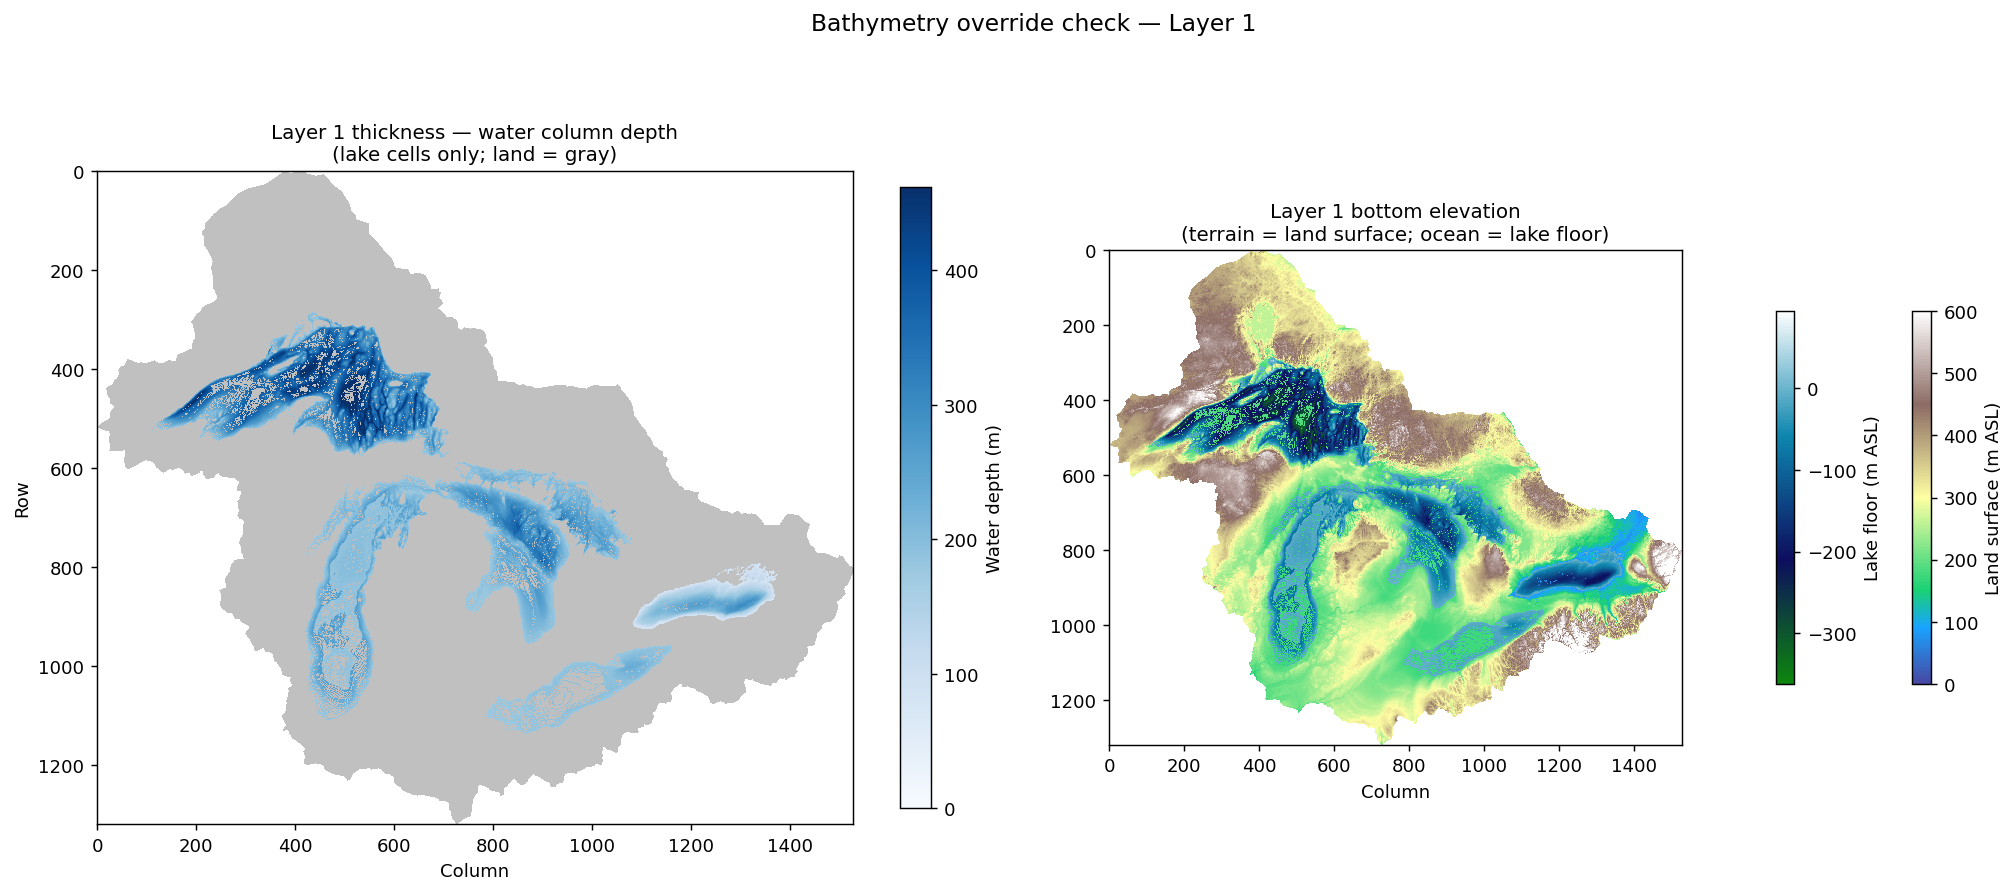

In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=130)

active = id2d == 1
lake   = lake_bathy_mask          # cells where bathymetry was applied

# ── LEFT: water-column depth at lake cells; land shown as neutral gray ─────
depth_all = top2d - botm3d[0]     # ~0.25 m on land, full depth on lakes

# gray background for active land cells
land_gray = np.full_like(depth_all, np.nan)
land_gray[active & ~lake] = 1.0
axes[0].imshow(land_gray, origin="upper", cmap="Greys", vmin=0, vmax=1,
               alpha=0.25, interpolation="nearest")

# blue water depth (lakes only)
lake_depth = np.where(lake, depth_all, np.nan)
vmax_depth = np.nanpercentile(lake_depth, 99)          # clip extreme outliers
im0 = axes[0].imshow(lake_depth, origin="upper", cmap="Blues",
                     vmin=0, vmax=vmax_depth, interpolation="nearest")
plt.colorbar(im0, ax=axes[0], label="Water depth (m)", shrink=0.75)
axes[0].set_title("Layer 1 thickness — water column depth\n(lake cells only; land = gray)",
                  fontsize=11)
axes[0].set_xlabel("Column"); axes[0].set_ylabel("Row")

# ── RIGHT: land topography + lake-floor elevation on one map ───────────────
b0 = botm3d[0].copy()

# land surface elevation
land_elev = np.where(active & ~lake, top2d, np.nan)
im1 = axes[1].imshow(land_elev, origin="upper", cmap="terrain",
                     vmin=0, vmax=600, interpolation="nearest", alpha=0.9)
cb1 = plt.colorbar(im1, ax=axes[1], label="Land surface (m ASL)",
                   shrink=0.45, pad=0.02, location="right")

# lake-floor elevation (overlaid)
lake_floor = np.where(lake, b0, np.nan)
floor_min  = np.nanmin(lake_floor)
floor_max  = np.nanmax(lake_floor)
im2 = axes[1].imshow(lake_floor, origin="upper", cmap="ocean",
                     vmin=floor_min, vmax=floor_max,
                     interpolation="nearest", alpha=0.95)
cb2 = plt.colorbar(im2, ax=axes[1], label="Lake floor (m ASL)",
                   shrink=0.45, pad=0.12, location="right")

axes[1].set_title("Layer 1 bottom elevation\n(terrain = land surface; ocean = lake floor)",
                  fontsize=11)
axes[1].set_xlabel("Column")

plt.suptitle("Bathymetry override check — Layer 1", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("layer1_bottom_check_v2.png", dpi=150, bbox_inches="tight")
plt.show()

## 10) Time discretization and recharge

This builds monthly stress periods and recharge arrays from the indexed recharge inputs.
After recharge is built, recharge is forced to zero over **active lake cells**.


In [13]:
# use boundary CRS as the destination CRS for reprojection
grid_crs_wkt = gpd.read_file(boundary_shp).crs.to_wkt()
print("Destination CRS loaded from boundary.")
print(grid_crs_wkt[:120], "...")

Destination CRS loaded from boundary.
PROJCRS["NAD83 / Great Lakes Albers",BASEGEOGCRS["NAD83",DATUM["North American Datum 1983",ELLIPSOID["GRS 1980",6378137, ...


In [14]:
# ---------------------------------------------------------
# BUILD MODEL MONTHS / PERIODS
# ---------------------------------------------------------
perioddata, months = build_monthly_perioddata(START_DATE, END_DATE)
nper = len(perioddata)
print("Stress periods in full run:", nper)

# ---------------------------------------------------------
# INDEX NLDAS FILES
# ---------------------------------------------------------
df_nc = index_blend_qsb_monthlies(nldas_root)

# force all dates to month-start timestamps so matching is consistent
df_nc = df_nc.copy()
df_nc["date"] = (
    pd.DatetimeIndex(df_nc["date"])
    .to_period("M")
    .to_timestamp(how="start")
)

expected = (
    pd.date_range(START_DATE, END_DATE, freq="MS")
    .to_period("M")
    .to_timestamp(how="start")
)

missing = expected.difference(df_nc["date"])
print("Missing NLDAS months:", len(missing))
if len(missing) > 0:
    print("First missing months:", list(missing[:10]))

# ---------------------------------------------------------
# SUBSET RUN PERIODS
# ---------------------------------------------------------
if NPER_TEST is not None:
    perioddata_run = perioddata[:NPER_TEST]
    months_run = months[:NPER_TEST]
else:
    perioddata_run = perioddata
    months_run = months

months_run = (
    pd.DatetimeIndex(months_run)
    .to_period("M")
    .to_timestamp(how="start")
)

print("Running nper =", len(perioddata_run))
print("Run dates:", months_run[0], "to", months_run[-1])

df_nc_run = df_nc[df_nc["date"].isin(months_run)].copy()

# ---------------------------------------------------------
# GET DESTINATION CRS FROM BOUNDARY, NOT template_tif
# this avoids relying on tmp.crs inside rasterio
# ---------------------------------------------------------
grid_crs_wkt = gpd.read_file(boundary_shp).crs.to_wkt()

# ---------------------------------------------------------
# BUILD RECHARGE STRESS-PERIOD ARRAYS
# ---------------------------------------------------------
rch_spd = build_rch_spd_from_index(
    df_nc=df_nc_run,
    months_run=months_run,
    template_tif=template_tif,
    id2d=id2d,
    var=NLDAS_VAR,
    dst_crs_wkt=grid_crs_wkt,   # <-- new
)

print("Recharge stress periods built:", len(rch_spd))
first_key = sorted(rch_spd.keys())[0]
print(
    "Recharge sample min/max:",
    float(np.nanmin(rch_spd[first_key])),
    float(np.nanmax(rch_spd[first_key]))
)

# ---------------------------------------------------------
# STEADY-STATE RECHARGE ARRAY
# note: this computes it, but does NOT prepend a new SS period
# unless you uncomment the block below
# ---------------------------------------------------------
rch_all_arr = np.array([rch_spd[p] for p in range(len(rch_spd))], dtype=float)
rch_mean_ss = np.nanmean(rch_all_arr, axis=0)
rch_mean_ss[id2d <= 0] = 0.0
rch_mean_ss[~np.isfinite(rch_mean_ss)] = 0.0

# steady-state period: 10 years, 1 timestep, multiplier 1.0
# SS_YEARS = 1
# ss_period = (365.0 * SS_YEARS, 1, 1.0)

# prepend SS period to perioddata_run
# perioddata_run = [ss_period] + list(perioddata_run)

# shift all existing rch_spd keys up by 1, add SS period as key 0
# rch_spd_new = {0: rch_mean_ss}
# for old_per, arr in rch_spd.items():
#     rch_spd_new[old_per + 1] = arr
# rch_spd = rch_spd_new

print("\n--- Recharge build complete ---")
print(f"Total stress periods in run: {len(perioddata_run)}")
print(f"rch_spd periods: {len(rch_spd)}")
print(
    f"Recharge SS-style mean min/max: "
    f"{float(np.nanmin(rch_mean_ss[id2d > 0])):.2e} / "
    f"{float(np.nanmax(rch_mean_ss[id2d > 0])):.2e} m/day"
)

Stress periods in full run: 48
Missing NLDAS months: 0
Running nper = 13
Run dates: 2020-01-01 00:00:00 to 2021-01-01 00:00:00
Recharge stress periods built: 13
Recharge sample min/max: 0.0 0.0030043579172343016

--- Recharge build complete ---
Total stress periods in run: 13
rch_spd periods: 13
Recharge SS-style mean min/max: 0.00e+00 / 1.72e-03 m/day


In [15]:

# ---------------------------------------------------------
# ZERO RECHARGE OVER ACTIVE GREAT LAKES CELLS
# ---------------------------------------------------------
for per in rch_spd:
    arr = np.asarray(rch_spd[per], dtype=float).copy()
    arr[lake_mask_2d] = 0.0
    rch_spd[per] = arr.astype("float32")

print("Recharge over active lake cells set to 0 for all periods.")


Recharge over active lake cells set to 0 for all periods.


In [16]:
# ============================================================
# SAVE rch_spd FOR USE IN OUTPUT NOTEBOOK
# ============================================================
# rch_spd is a dict {stress_period_int: 2D float32 array}.
# Saved as compressed npz so the output notebook can reload
# it without re-running the full simulation build.
rch_save_path = os.path.join(sim_ws, 'rch_spd.npz')
np.savez_compressed(rch_save_path, **{str(k): v for k, v in rch_spd.items()})
print(f'Saved rch_spd ({len(rch_spd)} periods) to:', rch_save_path)


Saved rch_spd (13 periods) to: D:\Users\abolmaal\modelling\Modflow\Testing_6\rch_spd.npz


### 10a) Recharge check over lake cells

This diagnostic confirms that recharge is zero over the active lake mask.


In [17]:

lake_rch_max = np.nan
lake_rch_any_nonzero = False

if "lake_mask_2d" not in globals():
    print("lake_mask_2d not found")
else:
    max_list = []
    for p in rch_spd:
        arr = np.asarray(rch_spd[p], dtype=float)

        if arr.shape != lake_mask_2d.shape:
            print(f"Skipping period {p}: shape mismatch {arr.shape} vs {lake_mask_2d.shape}")
            continue

        vals = arr[lake_mask_2d]
        vals = vals[np.isfinite(vals)]

        if vals.size > 0:
            max_list.append(vals.max())
            lake_rch_any_nonzero = lake_rch_any_nonzero or np.any(vals > 0)

    if len(max_list) > 0:
        lake_rch_max = max(max_list)

print("Max recharge over lake cells:", lake_rch_max)
print("Any non-zero recharge over lake cells:", lake_rch_any_nonzero)

Max recharge over lake cells: 0.0
Any non-zero recharge over lake cells: False


## 11) Build the General-Head Boundary (GHB)

Order matters here:
1. define GHB settings
2. rebuild the GHB cell table on the **current model grid**
3. build transient GHB stress-period data
4. run post-GHB diagnostics


In [18]:
# =========================================================
# PART 9.5 — GHB SOURCE SETTINGS
# =========================================================

# GHB footprint: full Great Lakes polygons (entire lakebed, not a 10 km ring).
# pathInputGHBFeature points to GreatLakes_GHB_fullLake.shp produced by
# CreateModflowInput.ipynb Cell 32. DO NOT use GreatLakes_GHB_cells.csv here.

# field in that GIS layer that contains lake names
lake_name_field = "lake_name"   # change if needed

print("GHB source feature:", pathInputGHBFeature)
print("Lake name field:", lake_name_field)
print("OUT_GHB_TABLE:", OUT_GHB_TABLE)
print("OUT_STAGE_TABLE:", OUT_STAGE_TABLE)
print("GHB_BED_THICKNESS_M:", GHB_BED_THICKNESS_M)
print("GHB_KV_DIVISOR:", GHB_KV_DIVISOR)

GHB source feature: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_buffer10km.shp
Lake name field: lake_name
OUT_GHB_TABLE: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_GHB_cells.csv
OUT_STAGE_TABLE: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_stage_monthly_for_model.csv
GHB_BED_THICKNESS_M: 1.0
GHB_KV_DIVISOR: 10.0


In [19]:
# =========================================================
# PART 9.6 — REBUILD GHB CELL TABLE ON CURRENT GRID
# =========================================================
# ---------------------------------------------------------
# build current model grid + GridIntersect
# ---------------------------------------------------------
structuredGrid = flopy.discretization.StructuredGrid(
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    xoff=xorigin,
    yoff=yorigin,
    angrot=0.0,
)

ix = make_gridintersect(structuredGrid)

# ---------------------------------------------------------
# intersect current GHB source feature with current grid
# ---------------------------------------------------------
ghb_src = intersect_grid_feature(
    ix=ix,
    pathFeature=pathInputGHBFeature,
    lay=0,
    addFields=[lake_name_field],
    grid_crs=grid_crs,
)

if ghb_src.empty:
    raise ValueError("No intersections found. Check pathInputGHBFeature, lake_name_field, and CRS.")

print("Raw GHB intersections:", len(ghb_src))
print("Columns:", ghb_src.columns.tolist())

# ---------------------------------------------------------
# standardize lake names
# ---------------------------------------------------------
if lake_name_field not in ghb_src.columns:
    raise ValueError(f"Field '{lake_name_field}' not found in source feature.")

ghb_src = ghb_src.copy()
ghb_src["lake_name"] = ghb_src[lake_name_field].astype(str).str.strip()

valid_lakes = {"Superior", "Michigan", "Huron", "Erie", "Ontario"}
ghb_src = ghb_src[ghb_src["lake_name"].isin(valid_lakes)].copy()

if ghb_src.empty:
    raise ValueError("No valid Great Lakes names found in source feature.")

# ---------------------------------------------------------
# get overlap area
# ---------------------------------------------------------
if "areas" in ghb_src.columns:
    ghb_src["overlap_m2"] = pd.to_numeric(ghb_src["areas"], errors="coerce")
elif "area" in ghb_src.columns:
    ghb_src["overlap_m2"] = pd.to_numeric(ghb_src["area"], errors="coerce")
else:
    raise ValueError(
        "No polygon overlap area column found. "
        "Your GHB source feature should be a polygon/band feature, not a line."
    )

ghb_src = ghb_src[ghb_src["overlap_m2"].notna() & (ghb_src["overlap_m2"] > 0)].copy()

# ---------------------------------------------------------
# assign current grid indices
# ---------------------------------------------------------
ghb_src["i"] = ghb_src["row"].astype(int)
ghb_src["j"] = ghb_src["col"].astype(int)
ghb_src["k"] = 0

# ---------------------------------------------------------
# keep only active top-layer cells
# ---------------------------------------------------------
if idomain.ndim == 3:
    active_top = idomain[0] > 0
else:
    active_top = idomain > 0

rr = ghb_src["i"].to_numpy(dtype=int)
cc = ghb_src["j"].to_numpy(dtype=int)

keep = (
    (rr >= 0) & (rr < nrow) &
    (cc >= 0) & (cc < ncol) &
    active_top[rr, cc]
)

ghb_src = ghb_src.loc[keep].copy()

if ghb_src.empty:
    raise ValueError("All GHB cells were removed by current idomain.")

# ---------------------------------------------------------
# hydraulic properties from current grid
# ---------------------------------------------------------
rr = ghb_src["i"].to_numpy(dtype=int)
cc = ghb_src["j"].to_numpy(dtype=int)

ghb_src["cell_area_m2"] = delr[cc] * delc[rr]
ghb_src["hk_mday"] = hk3d[0, rr, cc].astype(float)
ghb_src["kv_mday"] = np.maximum(ghb_src["hk_mday"] / GHB_KV_DIVISOR, 1e-8)

# conductance
ghb_src["cond"] = (
    ghb_src["kv_mday"] * ghb_src["overlap_m2"] / float(GHB_BED_THICKNESS_M)
).astype(float)

# ---------------------------------------------------------
# map stage names to stage-table columns
# ---------------------------------------------------------
ghb_src["stage_name"] = ghb_src["lake_name"].replace({
    "Superior": "Superior",
    "Michigan": "Michigan-Huron",
    "Huron": "Michigan-Huron",
    "Erie": "Erie",
    "Ontario": "Ontario",
})

ghb_src["bname"] = ghb_src.apply(
    lambda r: f"{r['lake_name']}_{int(r['i'])}_{int(r['j'])}",
    axis=1,
)

# ---------------------------------------------------------
# collapse duplicates per cell
# ---------------------------------------------------------
ghb_cells_df = (
    ghb_src.groupby(["lake_name", "stage_name", "k", "i", "j", "bname"], as_index=False)
    .agg(
        overlap_m2=("overlap_m2", "sum"),
        cell_area_m2=("cell_area_m2", "first"),
        hk_mday=("hk_mday", "first"),
        kv_mday=("kv_mday", "first"),
        cond=("cond", "sum"),
    )
)

ghb_cells_df = ghb_cells_df[ghb_cells_df["cond"] > 0].copy()

# save
ghb_cells_df.to_csv(OUT_GHB_TABLE, index=False)

print("Saved rebuilt GHB table:")
print(OUT_GHB_TABLE)
print()
print("Rebuilt GHB lakes:", sorted(ghb_cells_df["lake_name"].unique()))
print(ghb_cells_df["lake_name"].value_counts().sort_index())
print()
print("Rebuilt i range:", int(ghb_cells_df["i"].min()), int(ghb_cells_df["i"].max()))
print("Rebuilt j range:", int(ghb_cells_df["j"].min()), int(ghb_cells_df["j"].max()))
print("Current grid shape:", (nrow, ncol))

Raw GHB intersections: 99100
Columns: ['cellids', 'cellid', 'row', 'col', 'ixshapes', 'areas', 'lake_name']
Saved rebuilt GHB table:
D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_GHB_cells.csv

Rebuilt GHB lakes: ['Erie', 'Huron', 'Michigan', 'Ontario', 'Superior']
lake_name
Erie        11885
Huron       27170
Michigan    22376
Ontario      9173
Superior    28496
Name: count, dtype: int64

Rebuilt i range: 286 1137
Rebuilt j range: 107 1373
Current grid shape: (1319, 1527)


In [20]:
# =========================================================
# PART 10 — BUILD TRANSIENT GHB STRESS-PERIOD DATA
# =========================================================
# ---------------------------------------------------------
# read rebuilt GHB cells + monthly stage table
# ---------------------------------------------------------
ghb_cells_df = pd.read_csv(OUT_GHB_TABLE, low_memory=False)
monthly_stages_model = pd.read_csv(OUT_STAGE_TABLE, index_col=0, parse_dates=True)

# normalize monthly stage index to month-start
monthly_stages_model.index = (
    pd.DatetimeIndex(monthly_stages_model.index)
    .to_period("M")
    .to_timestamp(how="start")
)

# use same months as TDIS — subtract 1 because period 0 is SS not a calendar month
model_months = build_model_months("2000-01-01", len(perioddata_run) - 1)

# ---------------------------------------------------------
# standardize lake / stage names
# ---------------------------------------------------------
ghb_cells_df["lake_name"] = ghb_cells_df["lake_name"].astype(str).str.strip()
ghb_cells_df["stage_name"] = ghb_cells_df["lake_name"].replace({
    "Superior": "Superior",
    "Michigan": "Michigan-Huron",
    "Huron": "Michigan-Huron",
    "Erie": "Erie",
    "Ontario": "Ontario",
})

# ---------------------------------------------------------
# check stage columns exist
# ---------------------------------------------------------
needed_stage_names = sorted(set(ghb_cells_df["stage_name"]))
missing_stage_names = [nm for nm in needed_stage_names
                       if nm not in monthly_stages_model.columns]
if missing_stage_names:
    raise ValueError(f"Missing stage columns in stage table: {missing_stage_names}")

# ---------------------------------------------------------
# check month coverage
# ---------------------------------------------------------
missing_months = [dt for dt in model_months
                  if dt not in monthly_stages_model.index]
if missing_months:
    raise ValueError(
        f"Stage table is missing {len(missing_months)} model months. "
        f"First missing month: {missing_months[0]}"
    )

# ---------------------------------------------------------
# choose GHB layer k using minimum lake stage over modeled period
# ---------------------------------------------------------
stage_floor_by_name = monthly_stages_model.loc[
    model_months, needed_stage_names
].min()

print("Minimum stage by lake used for GHB layer assignment:")
print(stage_floor_by_name)

ghb_cells_df = assign_ghb_k_from_stage_floor(
    ghb_cells_df=ghb_cells_df,
    idomain=idomain,
    botm3d=botm3d,
    stage_floor_by_name=stage_floor_by_name,
    stage_margin=0.05,
)

print("Prepared GHB cells after stage-aware update:", len(ghb_cells_df))
print("GHB lakes:", sorted(ghb_cells_df["lake_name"].unique()))
print("Per-lake counts after k assignment:")
print(ghb_cells_df["lake_name"].value_counts().sort_index())

# ---------------------------------------------------------
# sanity check: every GHB cell bottom must be below stage floor
# ---------------------------------------------------------
bad = []
for r in ghb_cells_df.itertuples(index=False):
    stg = float(stage_floor_by_name[r.stage_name])
    btm = float(botm3d[int(r.k), int(r.i), int(r.j)])
    if not (stg > btm):
        bad.append((r.stage_name, int(r.k), int(r.i), int(r.j), stg, btm))

print("Bad GHB cells after reassignment:", len(bad))
if len(bad) > 0:
    print("First 10 bad cells:")
    print(bad[:10])
    raise ValueError("Some GHB cells still have stage <= cell bottom")

# ---------------------------------------------------------
# REDUCE GHB CONDUCTANCE
# ---------------------------------------------------------
# GHB_COND_MULT set in config.py
ghb_cells_df["cond"] = ghb_cells_df["cond"] * GHB_COND_MULT

print("GHB conductance multiplied by", GHB_COND_MULT)
print("GHB cond min/max:",
      ghb_cells_df["cond"].min(),
      ghb_cells_df["cond"].max())

# ---------------------------------------------------------
# ADD top_cap to ghb_cells_df
# ---------------------------------------------------------
rr = ghb_cells_df["i"].to_numpy(dtype=int)
cc = ghb_cells_df["j"].to_numpy(dtype=int)
ghb_cells_df["top_cap"] = top2d[rr, cc]

print("top_cap min/max:",
      ghb_cells_df["top_cap"].min(),
      ghb_cells_df["top_cap"].max())

print("Cells where stage_floor > top_cap:",
      int(np.sum(
          stage_floor_by_name[ghb_cells_df["stage_name"].values].values
          > ghb_cells_df["top_cap"].values
      )))

# ---------------------------------------------------------
# BUILD TRANSIENT ghb_spd — one entry per modeled month
# temporary keys 0..N-1 for transient months only
# ---------------------------------------------------------
# STAGE_CAP_OFFSET set in config.py

ghb_spd_transient = {}
for iper, dt in enumerate(model_months):
    recs = []
    for r in ghb_cells_df.itertuples(index=False):
        raw_stage = float(monthly_stages_model.loc[dt, r.stage_name])
        stage = min(raw_stage, float(r.top_cap) - STAGE_CAP_OFFSET)
        recs.append((
            (int(r.k), int(r.i), int(r.j)),
            stage,
            float(r.cond),
            str(r.bname),
        ))
    ghb_spd_transient[iper] = recs

print("\nGHB stress periods (transient only):", len(ghb_spd_transient))
print("GHB maxbound:", max(len(v) for v in ghb_spd_transient.values()))
print("Same GHB count each period?",
      all(len(v) == len(ghb_spd_transient[0]) for v in ghb_spd_transient.values()))

n_capped = sum(
    1 for r in ghb_cells_df.itertuples(index=False)
    if float(monthly_stages_model.loc[model_months[0], r.stage_name])
       > float(r.top_cap) - STAGE_CAP_OFFSET
)
print(f"GHB cells with stage capped in first transient month: {n_capped:,} of {len(ghb_cells_df):,}")

# ---------------------------------------------------------
# SHIFT ghb_spd TO ACCOUNT FOR STEADY-STATE PERIOD 0
# Period 0 = SS spin-up -> use first transient month stage
# Periods 1..N = transient months shifted by +1
# ---------------------------------------------------------
ghb_spd = {0: ghb_spd_transient[0]}

for old_per, recs in ghb_spd_transient.items():
    ghb_spd[old_per + 1] = recs

print("\nGHB stress periods after SS shift:", len(ghb_spd))
print("ghb_spd keys (first 5):", sorted(ghb_spd.keys())[:5])
print("ghb_spd keys (last):", sorted(ghb_spd.keys())[-1])

# ---------------------------------------------------------
# FINAL CONSISTENCY CHECK
# ---------------------------------------------------------
print("\n--- Period count consistency check ---")
print(f"perioddata_run: {len(perioddata_run)}")
print(f"ghb_spd:        {len(ghb_spd)}")

if len(ghb_spd) != len(perioddata_run):
    raise ValueError(
        f"ghb_spd has {len(ghb_spd)} periods but "
        f"perioddata_run has {len(perioddata_run)}. "
        f"They must match."
    )

print("✅ Period counts match")

Minimum stage by lake used for GHB layer assignment:
Erie              173.75
Michigan-Huron    175.81
Ontario            74.45
Superior          183.06
dtype: float64
GHB cells kept after stage-aware layer assignment: 99100
GHB cells dropped: 0
Prepared GHB cells after stage-aware update: 99100
GHB lakes: ['Erie', 'Huron', 'Michigan', 'Ontario', 'Superior']
Per-lake counts after k assignment:
lake_name
Erie        11885
Huron       27170
Michigan    22376
Ontario      9173
Superior    28496
Name: count, dtype: int64
Bad GHB cells after reassignment: 0
GHB conductance multiplied by 0.5
GHB cond min/max: 6.63464967998e-05 5000000.0
top_cap min/max: 62.66037368774414 441.79779052734375
Cells where stage_floor > top_cap: 27354

GHB stress periods (transient only): 12
GHB maxbound: 99100
Same GHB count each period? True
GHB cells with stage capped in first transient month: 54,274 of 99,100

GHB stress periods after SS shift: 13
ghb_spd keys (first 5): [0, 1, 2, 3, 4]
ghb_spd keys (last): 1

In [21]:
# =========================================================
# POST-GHB CHECKS
# Run this AFTER Part 10
# =========================================================

# ---------------------------------------------------------
# sanity check: every assigned GHB cell must have bottom below that lake's minimum stage
# ---------------------------------------------------------
bad = []
for r in ghb_cells_df.itertuples(index=False):
    stg = float(stage_floor_by_name[r.stage_name])
    btm = float(botm3d[int(r.k), int(r.i), int(r.j)])
    if not (stg > btm):
        bad.append((r.stage_name, int(r.k), int(r.i), int(r.j), stg, btm))

print("Bad GHB cells after reassignment:", len(bad))
if len(bad) > 0:
    print("First 10 bad cells:")
    print(bad[:10])
    raise ValueError("Some GHB cells still have stage <= cell bottom")

# ---------------------------------------------------------
# Build ring mask directly from rebuilt GHB cells
# ---------------------------------------------------------
ring_mask_2d = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    i, j = int(r.i), int(r.j)
    if (0 <= i < nrow) and (0 <= j < ncol):
        ring_mask_2d[i, j] = True

print(f"Ring cells: {int(ring_mask_2d.sum()):,}")

# ---------------------------------------------------------
# Check recharge over ring across all periods
# ---------------------------------------------------------
if ring_mask_2d.sum() == 0:
    print("No ring cells found on current grid; skipping recharge-over-ring check.")
    ring_rch_max = np.nan
    ring_rch_any_nonzero = False
else:
    ring_max_list = []
    ring_rch_any_nonzero = False

    for p in rch_spd:
        arr = np.asarray(rch_spd[p], dtype=float)

        if arr.shape != ring_mask_2d.shape:
            print(f"Skipping period {p}: recharge shape {arr.shape} does not match grid {ring_mask_2d.shape}")
            continue

        vals = arr[ring_mask_2d]
        vals = vals[np.isfinite(vals)]

        if vals.size > 0:
            ring_max_list.append(vals.max())
            ring_rch_any_nonzero = ring_rch_any_nonzero or np.any(vals > 0)

    ring_rch_max = max(ring_max_list) if len(ring_max_list) > 0 else np.nan

print(f"Max recharge over ring across all periods: {ring_rch_max}")
print(f"Any non-zero recharge over ring: {ring_rch_any_nonzero}")

Bad GHB cells after reassignment: 0
Ring cells: 99,091
Max recharge over ring across all periods: 0.0046904925256967545
Any non-zero recharge over ring: True


## 12) Prepare and build drains (DRN)

Drain workflow:
1. reset previous drain objects
2. build cleaned drain inputs
3. build raster-based stream/wetland drains
4. add optional surface-seepage drains
5. clean overlaps / tiny isolated drain clusters

Important logic in this workflow:
- drains are removed from active lake cells
- drains are removed from GHB cells
- raster drain stage is rebuilt from land surface (`top2d - DRN_DEPTH_M`)


In [22]:
# Force reset before rebuilding
drn_rec = []
surf_drn_rec = []
print("drn_rec and surf_drn_rec reset to empty")

drn_rec and surf_drn_rec reset to empty


In [23]:
# =========================================================
# PREP CLEAN DRAIN INPUTS
# Run AFTER:
#   - lake_mask_2d exists
#   - ghb_cells_df exists
# and BEFORE build_drn_from_raster(...)
# =========================================================

# DRN_DEPTH_M set in config.py

# -----------------------------
# GHB mask on model grid
# -----------------------------
ghb_mask_2d = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    i, j = int(r.i), int(r.j)
    if (0 <= i < nrow) and (0 <= j < ncol):
        ghb_mask_2d[i, j] = True

# -----------------------------
# Lake mask
# -----------------------------
if "lake_mask_2d" in globals():
    lake_mask = np.asarray(lake_mask_2d, dtype=bool) & (id2d == 1)
else:
    lake_mask = np.zeros((nrow, ncol), dtype=bool)

# -----------------------------
# Start from your current drain rasters
# -----------------------------
drain_frac2d_clean = np.array(drain_frac2d, dtype=float, copy=True)
drain_stage2d = np.full((nrow, ncol), np.nan, dtype=float)

# only where drain fraction exists in active cells
cand = (id2d == 1) & np.isfinite(drain_frac2d_clean) & (drain_frac2d_clean > 0)

# rebuild drain stage from land surface, not from raw drain_elev2d
drain_stage2d[cand] = top2d[cand] - DRN_DEPTH_M

# remove drains from lake cells
drain_frac2d_clean[lake_mask] = 0.0
drain_stage2d[lake_mask] = np.nan

# remove drains from GHB cells
drain_frac2d_clean[ghb_mask_2d] = 0.0
drain_stage2d[ghb_mask_2d] = np.nan

# remove inactive cells
drain_frac2d_clean[id2d <= 0] = 0.0
drain_stage2d[id2d <= 0] = np.nan

# clip area fraction
drain_frac2d_clean = np.clip(drain_frac2d_clean, 0.0, 1.0)

print("Drain candidate cells before exclusions:",
      int(np.count_nonzero((np.asarray(drain_frac2d, dtype=float) > 0) & (id2d == 1))))
print("Lake cells removed from drains:",
      int(np.count_nonzero((np.asarray(drain_frac2d, dtype=float) > 0) & lake_mask)))
print("GHB cells removed from drains:",
      int(np.count_nonzero((np.asarray(drain_frac2d, dtype=float) > 0) & ghb_mask_2d)))
print("Drain cells remaining:",
      int(np.count_nonzero((drain_frac2d_clean > 0) & np.isfinite(drain_stage2d))))

Drain candidate cells before exclusions: 714277
Lake cells removed from drains: 18630
GHB cells removed from drains: 24051
Drain cells remaining: 689641


In [24]:
dfDrn, drn_rec = build_drn_from_raster(
    drain_elev2d=drain_stage2d,
    drain_frac2d=drain_frac2d_clean,
    idomain=idomain,
    top2d=top2d,
    botm3d=botm3d,
    hk3d=hk3d,
    delr=delr,
    delc=delc,
    k_divisor=DRN_K_DIVISOR,
    cond_mult=DRN_COND_MULT,
    min_thick=DRN_MIN_THICK,
    min_area_frac=DRN_MIN_AREA_FRAC,
    elev_eps=DRN_ELEV_EPS,
)


In [25]:
# =========================================================
# SURFACE SEEPAGE FACES (horizontal surface drains)
# Eq. 13: Csurf = K * Ac / Tsoil
# Specified in every active land cell WITHOUT a river,
# wetland drain, or GHB (lake) cell.
# Cells with zero recharge are excluded to prevent
# draining cells that have no recharge source.
# =========================================================
# ---- save stream/wetland count before merging ----
n_stream_wet = len(drn_rec)

# ---- excluded cell set ----
existing_drn_ij = rec_to_ij_set(drn_rec)
existing_ghb_ij = ghb_to_ij_set(ghb_cells_df)

lake_ij = set()
if "lake_mask_2d" in globals():
    li, lj = np.where(np.asarray(lake_mask_2d, dtype=bool))
    lake_ij = set(zip(li.astype(int), lj.astype(int)))

excluded_ij = existing_drn_ij | existing_ghb_ij | lake_ij

# ---- mean annual recharge across all periods ----
rch_all = np.array([rch_spd[p] for p in range(len(rch_spd))],
                   dtype=float)
rch_mean_annual = np.nanmean(rch_all, axis=0)
rch_mean_annual[~np.isfinite(rch_mean_annual)] = 0.0

print("Active cells:", int(np.sum(idomain[SURF_DRN_LAY] > 0)))
print("Existing raster drain cells:", len(existing_drn_ij))
print("Existing GHB cells:", len(existing_ghb_ij))
print("Lake cells:", len(lake_ij))

remaining_mask = np.ones((nrow, ncol), dtype=bool)
remaining_mask &= (idomain[SURF_DRN_LAY] > 0)

excluded_mask = np.zeros((nrow, ncol), dtype=bool)
for i, j in excluded_ij:
    if 0 <= i < nrow and 0 <= j < ncol:
        excluded_mask[i, j] = True

remaining_mask &= (~excluded_mask)

print("Active cells left after exclusions:", int(remaining_mask.sum()))

vals = rch_mean_annual[remaining_mask]
vals = vals[np.isfinite(vals)]
print("Recharge summary in remaining cells:")
if vals.size > 0:
    print("  min   :", vals.min())
    print("  p50   :", np.percentile(vals, 50))
    print("  p95   :", np.percentile(vals, 95))
    print("  max   :", vals.max())
    print("  >= MIN_RECHARGE_MDAY :", int(np.sum(vals >= MIN_RECHARGE_MDAY)))
else:
    print("  no cells remaining")

# ---- build surface seepage records ----
surf_drn_rec = []
surf_rows    = []
n_skipped_inactive = 0
n_skipped_excluded = 0
n_weak_drain       = 0
n_normal_drain     = 0
for i in range(nrow):
    for j in range(ncol):
        if idomain[SURF_DRN_LAY, i, j] <= 0:
            n_skipped_inactive += 1
            continue
        if (i, j) in excluded_ij:
            n_skipped_excluded += 1
            continue

        elev = float(top2d[i, j]) - SURF_ELEV_OFFSET
        K    = float(hk3d[0, i, j])
        Ac   = float(delr[j] * delc[i])

        if rch_mean_annual[i, j] <= 0.0:
            Csurf = SURF_COND_WEAK
            n_weak_drain += 1
        else:
            Csurf_physical = K * (Ac * SURF_AREA_FRAC) / TSOIL_M
            rch_flux  = rch_mean_annual[i, j] * Ac
            Csurf_min = rch_flux * 10.0

            Csurf = max(Csurf_physical, Csurf_min)
            Csurf = min(Csurf, SURF_COND_CAP)
            n_normal_drain += 1

        if not np.isfinite(Csurf) or Csurf <= 0:
            continue

        surf_drn_rec.append(((SURF_DRN_LAY, i, j), elev, Csurf))
        surf_rows.append({
            "lay": SURF_DRN_LAY, "row": i, "col": j,
            "elev": elev, "K": K, "Ac": Ac, "cond": Csurf,
        })

dfSurfDrn = pd.DataFrame(surf_rows)
drn_rec = drn_rec + surf_drn_rec

print(f"Stream/wetland DRN cells:          {n_stream_wet:,}")
print(f"Skipped — inactive:                {n_skipped_inactive:,}")
print(f"Skipped — existing drain or GHB:   {n_skipped_excluded:,}")
print(f"Normal surface seepage cells:      {n_normal_drain:,}")
print(f"Weak drain cells (low recharge):   {n_weak_drain:,}")
print(f"Total surface seepage cells:       {len(surf_drn_rec):,}")
if len(dfSurfDrn) > 0:
    print(f"Csurf min/max: "
          f"{dfSurfDrn['cond'].min():.3e} / {dfSurfDrn['cond'].max():.3e}")
print(f"Total DRN records:                 {len(drn_rec):,}")

Active cells: 990009
Existing raster drain cells: 0
Existing GHB cells: 99091
Lake cells: 244693
Active cells left after exclusions: 738277
Recharge summary in remaining cells:
  min   : 0.0
  p50   : 0.0006327468268304634
  p95   : 0.0010720865357703028
  max   : 0.001719568006452531
  >= MIN_RECHARGE_MDAY : 738277
Stream/wetland DRN cells:          0
Skipped — inactive:                1,024,104
Skipped — existing drain or GHB:   251,732
Normal surface seepage cells:      734,238
Weak drain cells (low recharge):   4,039
Total surface seepage cells:       738,277
Csurf min/max: 1.000e-01 / 1.720e+04
Total DRN records:                 738,277


In [26]:
print("Total surface seepage cells:", len(surf_drn_rec))
print("Total DRN records:", len(drn_rec))

Total surface seepage cells: 738277
Total DRN records: 738277


In [27]:
print(f"Skipped — existing drain, GHB, or lake: {n_skipped_excluded:,}")

Skipped — existing drain, GHB, or lake: 251,732


In [28]:
# ---------------------------------------------------------
# GUARDS
# ---------------------------------------------------------
if "drn_rec" not in globals():
    raise RuntimeError("drn_rec is not defined. Run the DRN build cell first.")
if "surf_drn_rec" not in globals():
    raise RuntimeError("surf_drn_rec is not defined. Run the surface seepage cell first.")
if "ghb_cells_df" not in globals():
    raise RuntimeError("ghb_cells_df is not defined. Run the GHB cell first.")

# ---------------------------------------------------------
# SPLIT: stream/wetland vs surface seepage
# n_stream_wet was saved in the surface seepage cell
# ---------------------------------------------------------
stream_wet_rec = drn_rec[:n_stream_wet]   # raster drains only
surf_rec       = drn_rec[n_stream_wet:]   # surface seepage only

print("Stream/wetland records before cleanup:", len(stream_wet_rec))
print("Surface seepage records (not cleaned):", len(surf_rec))

# ---------------------------------------------------------
# BUILD MASKS FOR STREAM/WETLAND ONLY
# ---------------------------------------------------------
drn_mask = rec_list_to_bool_mask(stream_wet_rec, nrow, ncol)
ghb_mask = ghb_df_to_bool_mask(ghb_cells_df, nrow, ncol)

if "lake_mask_2d" in globals():
    lake_mask = np.asarray(lake_mask_2d, dtype=bool)
else:
    lake_mask = np.zeros((nrow, ncol), dtype=bool)

# remove GHB and lake overlap from stream/wetland drains
drn_mask = drn_mask & (~ghb_mask) & (~lake_mask)

# ---------------------------------------------------------
# REMOVE TINY ISOLATED COMPONENTS (stream/wetland only)
# ---------------------------------------------------------
structure = np.ones((3, 3), dtype=int)
labels, nlab = label(drn_mask, structure=structure)
sizes = np.bincount(labels.ravel())

keep_labels = np.where(sizes >= MIN_CLUSTER_SIZE)[0]
keep_labels = keep_labels[keep_labels != 0]
drn_mask_clean = np.isin(labels, keep_labels)

print("Stream/wetland cells before cluster filter:", int(drn_mask.sum()))
print("Stream/wetland cells after  cluster filter:", int(drn_mask_clean.sum()))
print("Removed:", int(drn_mask.sum() - drn_mask_clean.sum()))

# ---------------------------------------------------------
# REBUILD STREAM/WETLAND RECORDS FROM CLEAN MASK
# ---------------------------------------------------------
drn_rec_clean = []
for rec in stream_wet_rec:
    try:
        cellid, elev, cond = rec[:3]
        k, i, j = cellid
        if drn_mask_clean[int(i), int(j)]:
            drn_rec_clean.append(rec)
    except Exception:
        continue

# ---------------------------------------------------------
# FINAL MERGE: cleaned stream/wetland + surface seepage unchanged
# surface seepage covers the whole domain so cluster filter
# is not needed and must not be applied to it
# ---------------------------------------------------------
drn_rec = drn_rec_clean + surf_rec

# ---------------------------------------------------------
# CLEAN dfDrn DATAFRAME (stream/wetland rows only)
# ---------------------------------------------------------
if "dfDrn" in globals() and isinstance(dfDrn, pd.DataFrame) and len(dfDrn) > 0:
    if {"row", "col"}.issubset(dfDrn.columns):
        keep = [drn_mask_clean[int(i), int(j)]
                for i, j in zip(dfDrn["row"], dfDrn["col"])]
        dfDrn = dfDrn.loc[keep].copy()
    elif {"i", "j"}.issubset(dfDrn.columns):
        keep = [drn_mask_clean[int(i), int(j)]
                for i, j in zip(dfDrn["i"], dfDrn["j"])]
        dfDrn = dfDrn.loc[keep].copy()

# ---------------------------------------------------------
# SUMMARY
# ---------------------------------------------------------
print("\nStream/wetland DRN after cleanup:", len(drn_rec_clean))
print("Surface seepage DRN (unchanged): ", len(surf_rec))
print("Total final DRN records:         ", len(drn_rec))
if "dfDrn" in globals():
    print("dfDrn rows after cleanup:        ", len(dfDrn))

Stream/wetland records before cleanup: 0
Surface seepage records (not cleaned): 738277
Stream/wetland cells before cluster filter: 0
Stream/wetland cells after  cluster filter: 0
Removed: 0

Stream/wetland DRN after cleanup: 0
Surface seepage DRN (unchanged):  738277
Total final DRN records:          738277
dfDrn rows after cleanup:         0


## 13) Plot model inputs

This section makes a compact 3×3 summary of the current model inputs:
- TOP
- BOTM layer 1
- thickness layer 1
- Kh layer 1
- Kv layer 1
- recharge
- starting head
- DRN cells
- IDOMAIN + GHB cells


GHB cells identified for overlay: 99,091
Kh quantile bounds (10 edges):
  0.00864, 0.1996, 4.653, 9.76, 13.31, 18.04, 22.46, 22.67, 24.97, 100
Kv quantile bounds (10 edges):
  0.01275, 0.01996, 0.4653, 0.976, 1.331, 1.804, 2.246, 2.267, 2.497, 10


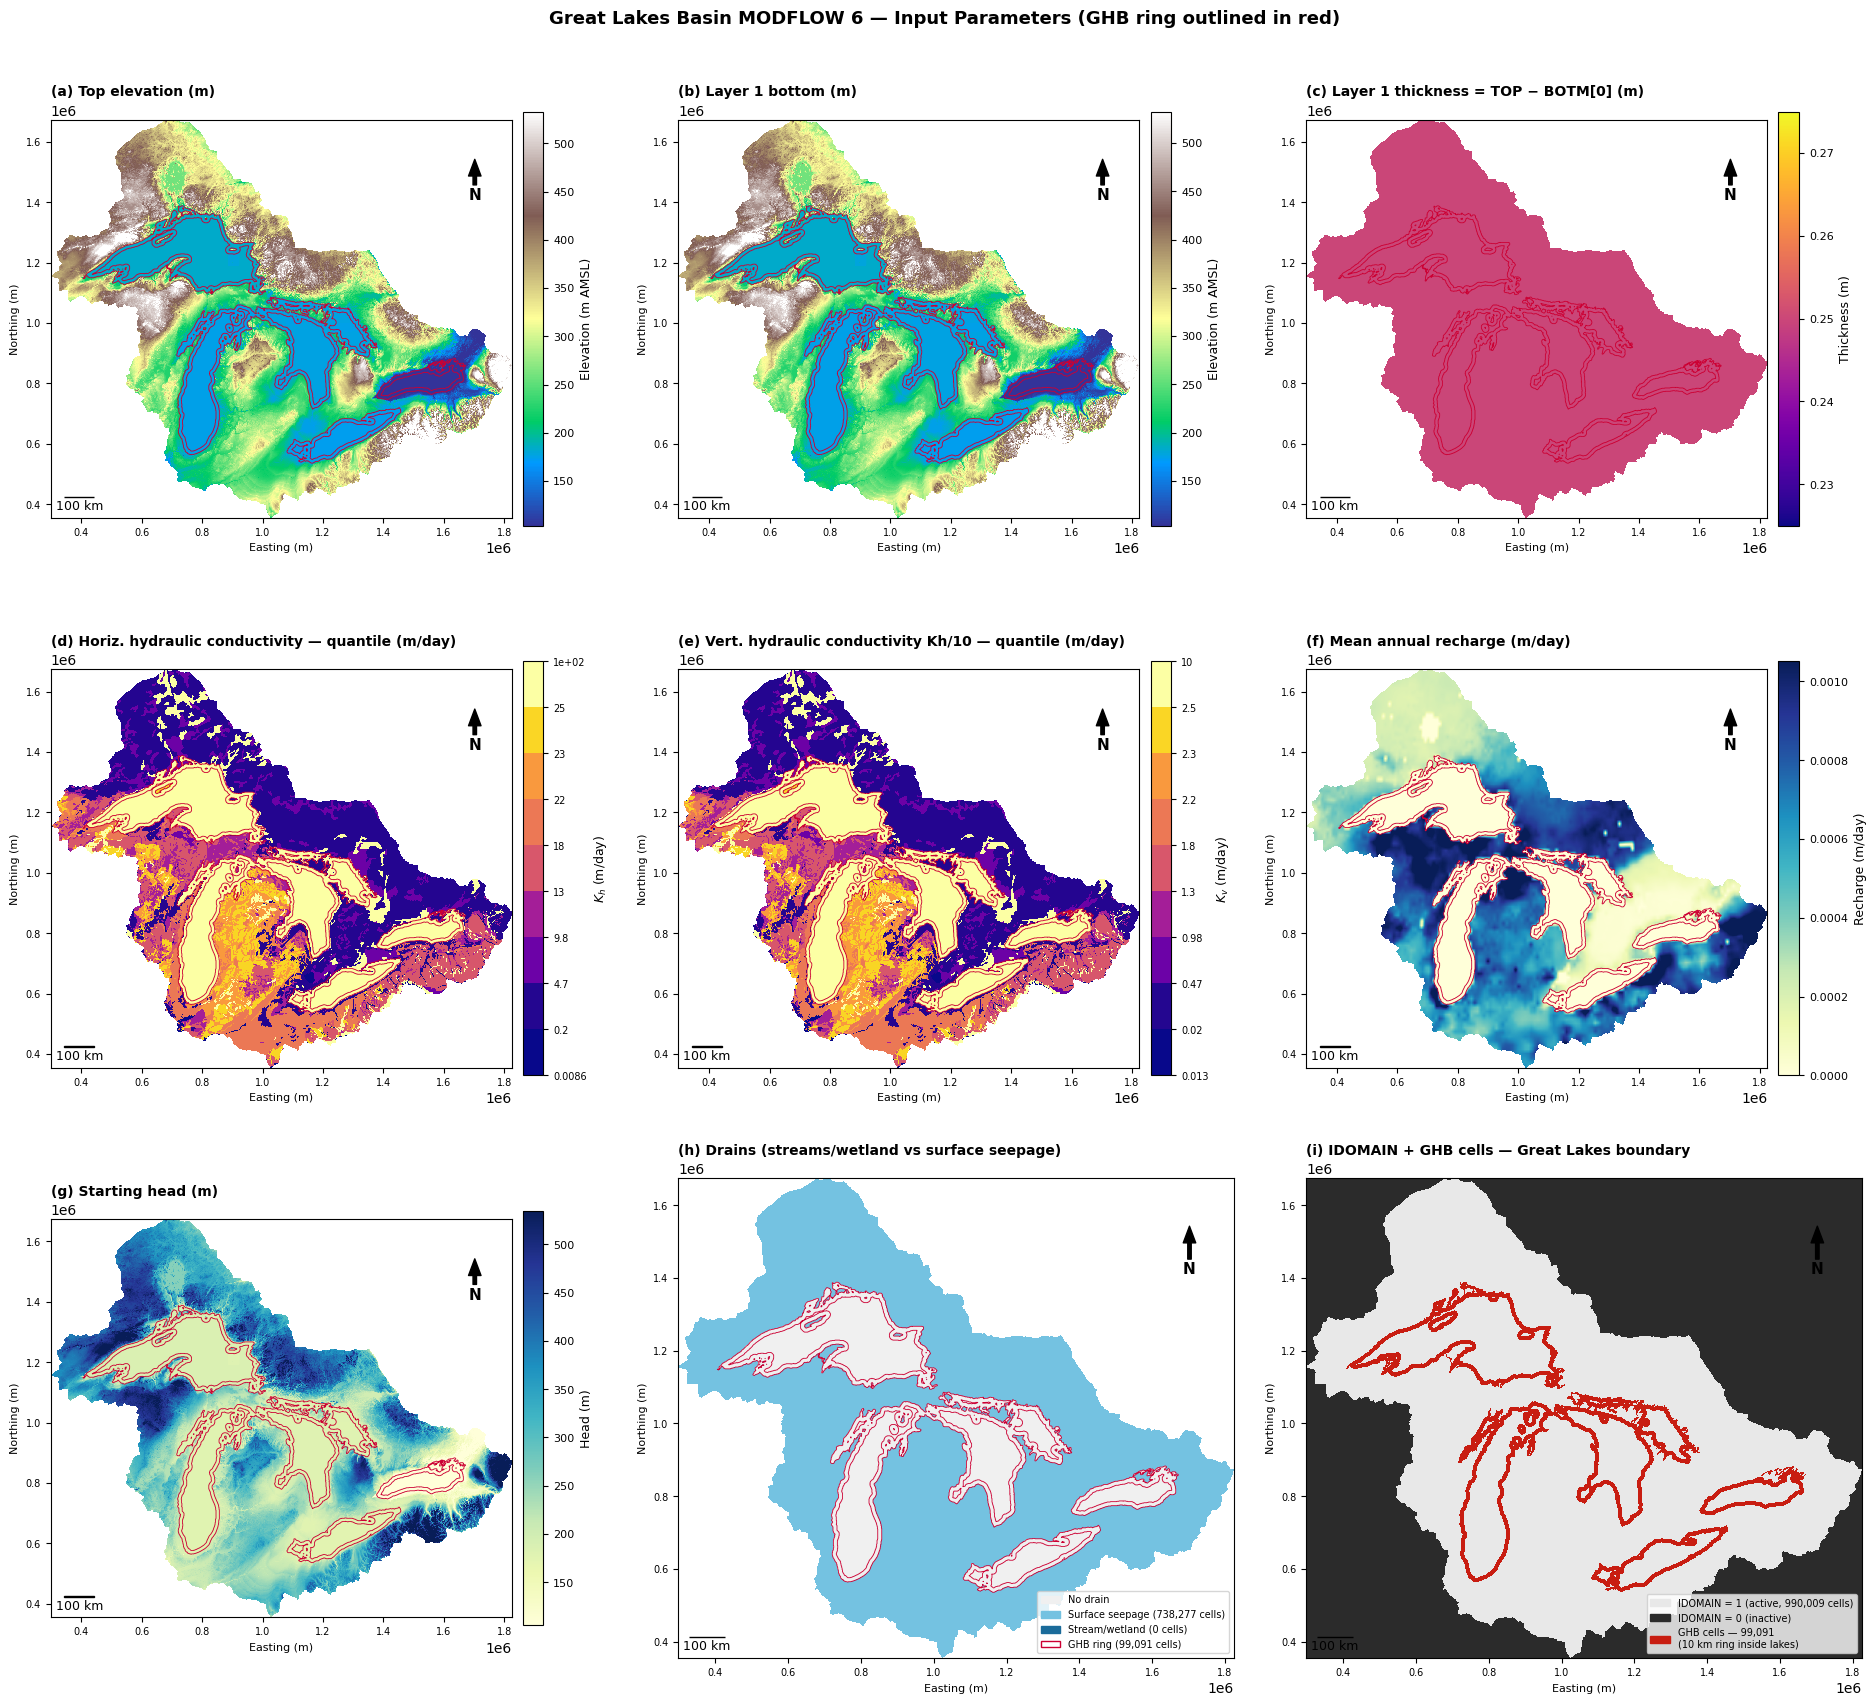

=== MODEL INPUT SUMMARY ===
Active cells total:           990,009
  terrestrial (land):         890,918
  GHB ring (in lake):          99,091

                       terrestrial        |   GHB ring
                  min      med     max    |  min    med    max
TOP           70 2.7e+02 1.1e+03 |     63 1.8e+02 4.4e+02 m
BOTM0         70 2.7e+02 1.1e+03 |     62 1.8e+02 4.4e+02 m
THK1        0.25    0.25    0.25 |   0.25   0.25   0.25 m
HK0        1e-08      13   1e+02 | 0.0086  1e+02  1e+02 m/day
K33        1e-09     1.3      10 | 0.00086     10     10 m/day
STRT          72 2.8e+02 1.1e+03 |     64 1.8e+02 4.4e+02 m
RCH            0 0.00051  0.0017 |      0      0 0.0013 m/day

DRN cells:  738,277
GHB cells:  99,091


In [29]:


# =========================================================
# HK QUANTILE COLORMAP — 15-class
# =========================================================
hk_colors_15 = [
    "#08088B",  # near black
    '#0D0887',  # deep blue
    '#2D0594',  # blue-purple
    '#5C01A6',  # violet
    '#7E03A8',  # magenta-purple
    '#9C179E',  # magenta
    '#BD3786',  # pink-magenta
    '#D8576B',  # salmon
    '#E8765C',  # light salmon
    '#ED7953',  # orange
    '#F89441',  # bright orange
    '#FB9F3A',  # light orange
    '#FDCA26',  # gold
    '#F0F921',  # yellow
    '#FCFFA4',  # pale yellow
]

hk_cmap = LinearSegmentedColormap.from_list('hk_15class', hk_colors_15, N=512)


# ---------------------------------------------------------
# prepare domain
# ---------------------------------------------------------
extent = get_plot_extent(xorigin, yorigin, delr, delc, nrow, ncol)

idomain2d = idomain[0] if idomain.ndim == 3 else id2d

# GHB cell mask directly from rebuilt GHB cells
ring_mask_2d = np.zeros((nrow, ncol), dtype=bool)
if "ghb_cells_df" in globals():
    for r in ghb_cells_df.itertuples(index=False):
        i, j = int(r.i), int(r.j)
        if 0 <= i < nrow and 0 <= j < ncol:
            ring_mask_2d[i, j] = True

n_ring = int(ring_mask_2d.sum())
print(f"GHB cells identified for overlay: {n_ring:,}")

# ---------------------------------------------------------
# arrays in MODEL UNITS as they enter MODFLOW 6
# ---------------------------------------------------------
top_plot = active_array(top2d, idomain2d)
bot1_plot = active_array(botm3d[0], idomain2d)
thk1_plot = active_array(top2d - botm3d[0], idomain2d)

hk1_plot = active_array(hk3d[0], idomain2d)
k33_plot = active_array(k33_3d[0], idomain2d)

rch_all  = np.array([rch_spd[p] for p in range(len(rch_spd))], dtype=float)
rch_mean = np.nanmean(rch_all, axis=0)
rch_mday = active_array(rch_mean, idomain2d)

strt1_plot = active_array(strt[0] if strt.ndim == 3 else strt, idomain2d)

idomain_plot = np.where(idomain2d == 1, 1.0, np.nan)

drn_mask = rec_list_to_mask(drn_rec, nrow, ncol)

ghb_mask = ghb_df_to_mask(ghb_cells_df, nrow, ncol) \
           if "ghb_cells_df" in globals() \
           else np.full((nrow, ncol), np.nan, dtype=float)

# ---------------------------------------------------------
# color limits — computed on terrestrial cells only
# ---------------------------------------------------------
terrestrial_mask = (idomain2d == 1) & (~ring_mask_2d)

top_vmin,  top_vmax  = pct_terrestrial(top_plot, 2, 98, terrestrial_mask)
bot_vmin,  bot_vmax  = pct_terrestrial(bot1_plot, 2, 98, terrestrial_mask)
thk_vmin,  thk_vmax  = pct_terrestrial(thk1_plot, 2, 98, terrestrial_mask)

# =========================================================
# QUANTILE BOUNDS for Kh and Kv (terrestrial cells only)
# =========================================================
hk_terr = hk3d[0].copy()
hk_terr[~terrestrial_mask] = np.nan

kv_terr = k33_3d[0].copy()
kv_terr[~terrestrial_mask] = np.nan

hk_bounds, _ = compute_quantile_bounds(hk_terr, N_CLASSES)
kv_bounds, _ = compute_quantile_bounds(kv_terr, N_CLASSES)

hk_norm = BoundaryNorm(hk_bounds, hk_cmap.N)
kv_norm = BoundaryNorm(kv_bounds, hk_cmap.N)

print(f"Kh quantile bounds ({len(hk_bounds)} edges):")
print("  " + ", ".join([f"{b:.4g}" for b in hk_bounds]))
print(f"Kv quantile bounds ({len(kv_bounds)} edges):")
print("  " + ", ".join([f"{b:.4g}" for b in kv_bounds]))

# =========================================================
# Recharge — keep in model units (m/day) for colorbar
# =========================================================
rch_vmin = 0.0
rch_vmax = float(np.nanpercentile(rch_mday[terrestrial_mask], 95))
strt_vmin, strt_vmax = pct_terrestrial(strt1_plot, 2, 98, terrestrial_mask)

# ---------------------------------------------------------
# PLOT — 3x3 grid
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(19, 17))
axes = axes.ravel()
letters = [f"({x})" for x in "abcdefghi"]

# (a) Top elevation
im = axes[0].imshow(np.ma.masked_invalid(top_plot),
                    origin="upper", extent=extent,
                    cmap="terrain", vmin=top_vmin, vmax=top_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[0], im, "Elevation (m AMSL)")
outline_ring(axes[0], ring_mask_2d, extent, n_ring)
base_ax(axes[0], letters[0], "Top elevation (m)")
add_north(axes[0]); add_scalebar(axes[0], delr, delc)

# (b) Layer 1 bottom
im = axes[1].imshow(np.ma.masked_invalid(bot1_plot),
                    origin="upper", extent=extent,
                    cmap="terrain", vmin=bot_vmin, vmax=bot_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[1], im, "Elevation (m AMSL)")
outline_ring(axes[1], ring_mask_2d, extent, n_ring)
base_ax(axes[1], letters[1], "Layer 1 bottom (m)")
add_north(axes[1]); add_scalebar(axes[1], delr, delc)

# (c) Layer 1 thickness
im = axes[2].imshow(np.ma.masked_invalid(thk1_plot),
                    origin="upper", extent=extent,
                    cmap="plasma", vmin=thk_vmin, vmax=thk_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[2], im, "Thickness (m)")
outline_ring(axes[2], ring_mask_2d, extent, n_ring)
base_ax(axes[2], letters[2], "Layer 1 thickness = TOP − BOTM[0] (m)")
add_north(axes[2]); add_scalebar(axes[2], delr, delc)

# =========================================================
# (d) Kh layer 1 — QUANTILE colormap
# =========================================================
hk1_for_plot = active_array(hk3d[0], idomain2d)

im = axes[3].imshow(np.ma.masked_invalid(hk1_for_plot),
                    origin="upper", extent=extent,
                    cmap=hk_cmap,
                    norm=hk_norm,
                    interpolation="nearest")

cb_hk = fig.colorbar(im, ax=axes[3], shrink=0.82, pad=0.02)
cb_hk.set_label(r"$K_h$ (m/day)", fontsize=9)

# label colorbar ticks at quantile boundaries
tick_positions = hk_bounds
tick_labels = [f"{v:.2g}" for v in hk_bounds]
# show every other tick to avoid crowding
if len(tick_positions) > 8:
    step = max(1, len(tick_positions) // 8)
    tick_positions_show = tick_positions[::step]
    tick_labels_show = tick_labels[::step]
    # always include last
    if tick_positions_show[-1] != tick_positions[-1]:
        tick_positions_show = np.append(tick_positions_show, tick_positions[-1])
        tick_labels_show.append(tick_labels[-1])
else:
    tick_positions_show = tick_positions
    tick_labels_show = tick_labels

cb_hk.set_ticks(tick_positions_show)
cb_hk.set_ticklabels(tick_labels_show)
cb_hk.ax.tick_params(labelsize=7)

outline_ring(axes[3], ring_mask_2d, extent, n_ring)
base_ax(axes[3], letters[3],
        "Horiz. hydraulic conductivity — quantile (m/day)")
add_north(axes[3]); add_scalebar(axes[3], delr, delc)

# =========================================================
# (e) Kv layer 1 — QUANTILE colormap (same color scale)
# =========================================================
k33_for_plot = active_array(k33_3d[0], idomain2d)

im = axes[4].imshow(np.ma.masked_invalid(k33_for_plot),
                    origin="upper", extent=extent,
                    cmap=hk_cmap,
                    norm=kv_norm,
                    interpolation="nearest")

cb_kv = fig.colorbar(im, ax=axes[4], shrink=0.82, pad=0.02)
cb_kv.set_label(r"$K_v$ (m/day)", fontsize=9)

tick_positions_kv = kv_bounds
tick_labels_kv = [f"{v:.2g}" for v in kv_bounds]
if len(tick_positions_kv) > 8:
    step = max(1, len(tick_positions_kv) // 8)
    tick_positions_kv_show = tick_positions_kv[::step]
    tick_labels_kv_show = tick_labels_kv[::step]
    if tick_positions_kv_show[-1] != tick_positions_kv[-1]:
        tick_positions_kv_show = np.append(tick_positions_kv_show, tick_positions_kv[-1])
        tick_labels_kv_show.append(tick_labels_kv[-1])
else:
    tick_positions_kv_show = tick_positions_kv
    tick_labels_kv_show = tick_labels_kv

cb_kv.set_ticks(tick_positions_kv_show)
cb_kv.set_ticklabels(tick_labels_kv_show)
cb_kv.ax.tick_params(labelsize=7)

outline_ring(axes[4], ring_mask_2d, extent, n_ring)
base_ax(axes[4], letters[4],
        "Vert. hydraulic conductivity Kh/10 — quantile (m/day)")
add_north(axes[4]); add_scalebar(axes[4], delr, delc)

# =========================================================
# (f) Mean annual recharge — model units (m/day) only
# =========================================================
im = axes[5].imshow(np.ma.masked_invalid(rch_mday),
                    origin="upper", extent=extent,
                    cmap="YlGnBu", vmin=rch_vmin, vmax=rch_vmax,
                    interpolation="nearest")
cb_rch = fig.colorbar(im, ax=axes[5], shrink=0.82, pad=0.02)
cb_rch.set_label("Recharge (m/day)", fontsize=9)
cb_rch.ax.tick_params(labelsize=8)

outline_ring(axes[5], ring_mask_2d, extent, n_ring)
base_ax(axes[5], letters[5],
        "Mean annual recharge (m/day)")
add_north(axes[5]); add_scalebar(axes[5], delr, delc)

# (g) Starting head
im = axes[6].imshow(np.ma.masked_invalid(strt1_plot),
                    origin="upper", extent=extent,
                    cmap="YlGnBu",
                    vmin=strt_vmin, vmax=strt_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[6], im, "Head (m)")
outline_ring(axes[6], ring_mask_2d, extent, n_ring)
base_ax(axes[6], letters[6],
        "Starting head (m)")
add_north(axes[6]); add_scalebar(axes[6], delr, delc)

# (h) DRN cells
drn_type = np.zeros((nrow, ncol), dtype=float)
drn_type[idomain2d <= 0] = np.nan
for rec in drn_rec_clean:
    k, i, j = rec[0]
    drn_type[i, j] = 2.0
for rec in surf_rec:
    k, i, j = rec[0]
    if drn_type[i, j] != 2.0:
        drn_type[i, j] = 1.0

cmap_drn = ListedColormap(["#f0f0f0", "#74c2e1", "#1a6b9a"])
axes[7].imshow(np.ma.masked_invalid(drn_type),
               origin="upper", extent=extent,
               cmap=cmap_drn, vmin=0, vmax=2,
               interpolation="nearest")
outline_ring(axes[7], ring_mask_2d, extent, n_ring)
axes[7].legend(handles=[
    Patch(color="#f0f0f0", label="No drain"),
    Patch(color="#74c2e1",
          label=f"Surface seepage ({len(surf_rec):,} cells)"),
    Patch(color="#1a6b9a",
          label=f"Stream/wetland ({len(drn_rec_clean):,} cells)"),
    Patch(edgecolor="#cc0033", facecolor="none",
          label=f"GHB ring ({n_ring:,} cells)"),
], loc="lower right", fontsize=7, frameon=True)
base_ax(axes[7], letters[7],
        "Drains (streams/wetland vs surface seepage)")
add_north(axes[7]); add_scalebar(axes[7], delr, delc)

# (i) GHB cells — filled ring with terrestrial background
idomain_bg = idomain2d.astype(float)
axes[8].imshow(idomain_bg,
               origin="upper", extent=extent,
               cmap=ListedColormap(["#2b2b2b", "#e8e8e8"]),
               vmin=0, vmax=1,
               interpolation="nearest")

axes[8].imshow(np.ma.masked_invalid(ghb_mask),
               origin="upper", extent=extent,
               cmap=ListedColormap(["#c81d11"]),
               vmin=0.5, vmax=1.5,
               interpolation="nearest")

axes[8].legend(handles=[
    Patch(color="#e8e8e8", label=f"IDOMAIN = 1 (active, {int((idomain2d == 1).sum()):,} cells)"),
    Patch(color="#2b2b2b", label=f"IDOMAIN = 0 (inactive)"),
    Patch(color="#c81d11",
          label=f"GHB cells — {int(np.isfinite(ghb_mask).sum()):,}\n"
                f"(10 km ring inside lakes)"),
], loc="lower right", fontsize=7, frameon=True)
base_ax(axes[8], letters[8],
        "IDOMAIN + GHB cells — Great Lakes boundary")
add_north(axes[8]); add_scalebar(axes[8], delr, delc)

plt.suptitle(
    "Great Lakes Basin MODFLOW 6 — Input Parameters (GHB ring outlined in red)",
    fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(r"D:\Users\abolmaal\modelling\Figs\Testing_6\modelinputs.jpeg",
            dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# summary in model units, split by terrestrial vs ring
# ---------------------------------------------------------
terr = terrestrial_mask
ring = ring_mask_2d

print("=== MODEL INPUT SUMMARY ===")
print(f"Active cells total:        {int(np.sum(idomain2d == 1)):>10,}")
print(f"  terrestrial (land):      {int(terr.sum()):>10,}")
print(f"  GHB ring (in lake):      {int(ring.sum()):>10,}")
print()
print("                       terrestrial        |   GHB ring")
print("                  min      med     max    |  min    med    max")
row("TOP", top2d, terr, ring, "m")
row("BOTM0", botm3d[0], terr, ring, "m")
row("THK1", top2d - botm3d[0], terr, ring, "m")
row("HK0", hk3d[0], terr, ring, "m/day")
row("K33", k33_3d[0], terr, ring, "m/day")
row("STRT", strt[0] if strt.ndim == 3 else strt, terr, ring, "m")
row("RCH", rch_mean, terr, ring, "m/day")
print()
print(f"DRN cells:  {len(drn_rec):,}")
print(f"GHB cells:  {int(np.isfinite(ghb_mask).sum()):,}")

## 14) Pre-run sanity checks

This is a good checkpoint before writing and running MODFLOW 6.
It checks:
- DRN conductance ranges
- duplicate drains
- DRN / GHB overlap
- GHB stage consistency
- recharge and head bounds


In [30]:
print("Recharge totals by stress period:")
for p in sorted(rch_spd.keys()):
    arr = np.asarray(rch_spd[p], dtype=float)
    arr = np.where(np.isfinite(arr), arr, 0.0)

    total = arr.sum() * float(delr[0] * delc[0])   # approximate if uniform 1000 m grid
    nonzero = int(np.count_nonzero(arr > 0))
    vmax = float(arr.max()) if arr.size else np.nan

    print(f"  period {p:2d}: total={total:.3e} m3/day, nonzero cells={nonzero:,}, max={vmax:.3e}")

Recharge totals by stress period:
  period  0: total=4.361e+08 m3/day, nonzero cells=740,776, max=3.004e-03
  period  1: total=2.869e+08 m3/day, nonzero cells=740,776, max=1.994e-03
  period  2: total=3.849e+08 m3/day, nonzero cells=740,776, max=4.637e-03
  period  3: total=6.297e+08 m3/day, nonzero cells=740,776, max=3.845e-03
  period  4: total=8.517e+08 m3/day, nonzero cells=740,776, max=5.286e-03
  period  5: total=6.761e+08 m3/day, nonzero cells=740,776, max=4.248e-03
  period  6: total=5.108e+08 m3/day, nonzero cells=740,484, max=3.403e-03
  period  7: total=2.721e+08 m3/day, nonzero cells=739,655, max=1.999e-03
  period  8: total=2.369e+08 m3/day, nonzero cells=739,304, max=2.328e-03
  period  9: total=3.770e+08 m3/day, nonzero cells=740,330, max=3.291e-03
  period 10: total=4.532e+08 m3/day, nonzero cells=740,776, max=2.808e-03
  period 11: total=3.032e+08 m3/day, nonzero cells=740,776, max=2.587e-03
  period 12: total=2.082e+08 m3/day, nonzero cells=740,776, max=1.961e-03


In [31]:
terr_mask = (idomain[0] > 0)
if "lake_mask_2d" in globals():
    terr_mask = terr_mask & (~lake_mask_2d)

print("\nRecharge over active land cells by period:")
for p in sorted(rch_spd.keys()):
    arr = np.asarray(rch_spd[p], dtype=float)
    vals = arr[terr_mask]
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        print(f"  period {p:2d}: no values")
    else:
        print(f"  period {p:2d}: min={vals.min():.3e}, p50={np.percentile(vals,50):.3e}, "
              f"p95={np.percentile(vals,95):.3e}, max={vals.max():.3e}, "
              f"nonzero={np.count_nonzero(vals>0):,}")


Recharge over active land cells by period:
  period  0: min=0.000e+00, p50=4.315e-04, p95=1.704e-03, max=3.004e-03, nonzero=740,776
  period  1: min=0.000e+00, p50=2.406e-04, p95=1.172e-03, max=1.994e-03, nonzero=740,776
  period  2: min=0.000e+00, p50=4.006e-04, p95=1.535e-03, max=4.637e-03, nonzero=740,776
  period  3: min=0.000e+00, p50=7.478e-04, p95=1.947e-03, max=3.845e-03, nonzero=740,776
  period  4: min=0.000e+00, p50=1.002e-03, p95=3.064e-03, max=5.286e-03, nonzero=740,776
  period  5: min=0.000e+00, p50=6.193e-04, p95=2.380e-03, max=4.248e-03, nonzero=740,776
  period  6: min=0.000e+00, p50=6.197e-04, p95=1.752e-03, max=3.403e-03, nonzero=740,484
  period  7: min=0.000e+00, p50=2.791e-04, p95=1.032e-03, max=1.999e-03, nonzero=739,655
  period  8: min=0.000e+00, p50=2.155e-04, p95=1.018e-03, max=2.328e-03, nonzero=739,304
  period  9: min=0.000e+00, p50=2.874e-04, p95=1.794e-03, max=3.291e-03, nonzero=740,330
  period 10: min=0.000e+00, p50=3.599e-04, p95=1.665e-03, max=2.80

In [32]:
print("=" * 60)
print("SANITY CHECKS BEFORE RUNNING MODFLOW 6")
print("=" * 60)

# ---------------------------------------------------------
# 1) SURFACE SEEPAGE CONDUCTANCE
# ---------------------------------------------------------
print("\n--- 1) Surface seepage conductance ---")
surf_conds = np.array([r[2] for r in surf_drn_rec])
print(f"  Csurf min:    {surf_conds.min():.3e} m²/day")
print(f"  Csurf max:    {surf_conds.max():.3e} m²/day")
print(f"  Csurf median: {np.median(surf_conds):.3e} m²/day")
print(f"  Cells at cap (1e4): {np.sum(surf_conds >= 9999):.0f}")

if surf_conds.max() > 1e6:
    print("  ❌ FAIL — Csurf max > 1e6, TSOIL/SURF_AREA_FRAC fix not applied")
elif surf_conds.max() > 1e5:
    print("  ⚠️  WARNING — Csurf max > 1e5, consider lowering SURF_COND_CAP")
else:
    print("  ✅ PASS — conductance range looks reasonable")

# ---------------------------------------------------------
# 2) DRAIN RECORD COUNTS AND NO DUPLICATES
# ---------------------------------------------------------
print("\n--- 2) DRN record counts ---")
print(f"  Stream/wetland records: {len(drn_rec_clean):,}")
print(f"  Surface seepage records: {len(surf_rec):,}")
print(f"  Total drn_rec: {len(drn_rec):,}")

# check for duplicate (i,j) cells in final drn_rec
ij_list = [(r[0][1], r[0][2]) for r in drn_rec]
ij_set  = set(ij_list)
n_dups  = len(ij_list) - len(ij_set)
print(f"  Duplicate (i,j) cells: {n_dups}")
if n_dups > 0:
    print("  ❌ FAIL — duplicate drain cells will cause MODFLOW budget errors")
else:
    print("  ✅ PASS — no duplicate drain cells")

# ---------------------------------------------------------
# 3) OVERLAP BETWEEN DRN AND GHB
# ---------------------------------------------------------
print("\n--- 3) DRN / GHB overlap ---")
drn_ij = {(r[0][1], r[0][2]) for r in drn_rec}
ghb_ij = {(int(r.i), int(r.j)) for r in ghb_cells_df.itertuples()}
overlap = drn_ij & ghb_ij
print(f"  DRN cells:  {len(drn_ij):,}")
print(f"  GHB cells:  {len(ghb_ij):,}")
print(f"  Overlap:    {len(overlap)}")
if len(overlap) > 0:
    print("  ❌ FAIL — DRN and GHB share cells, remove overlap before running")
else:
    print("  ✅ PASS — no DRN/GHB overlap")

# ---------------------------------------------------------
# 4) GHB STAGE vs CELL TOP
# ---------------------------------------------------------
print("\n--- 4) GHB stage vs land surface (top_cap check) ---")
if "top_cap" not in ghb_cells_df.columns:
    print("  ⚠️  top_cap column missing — GHB stage cap fix not applied")
else:
    rr = ghb_cells_df["i"].to_numpy(dtype=int)
    cc = ghb_cells_df["j"].to_numpy(dtype=int)
    first_per_stages = np.array([
        float(monthly_stages_model.loc[model_months[0], r.stage_name])
        for r in ghb_cells_df.itertuples(index=False)
    ])
    capped_stages = np.array([
        min(float(monthly_stages_model.loc[model_months[0], r.stage_name]),
            float(r.top_cap) - 0.10)
        for r in ghb_cells_df.itertuples(index=False)
    ])
    n_above = np.sum(first_per_stages > top2d[rr, cc])
    n_capped = np.sum(capped_stages < first_per_stages)
    print(f"  GHB cells where raw stage > top2d:   {n_above:,}")
    print(f"  GHB cells where stage was capped:    {n_capped:,}")
    if n_above > 0 and n_capped == 0:
        print("  ❌ FAIL — stage cap fix not active in ghb_spd loop")
    else:
        print("  ✅ PASS — stage cap applied to all cells above land surface")

# ---------------------------------------------------------
# 5) STARTING HEADS WITHIN VALID RANGE
# ---------------------------------------------------------
print("\n--- 5) Starting heads ---")
active = idomain[0] > 0
strt1 = strt[0]
above_top  = np.sum(strt1[active] > top2d[active])
below_bot  = np.sum(strt1[active] < botm3d[0][active])
print(f"  Cells with head > top2d:   {above_top:,}")
print(f"  Cells with head < botm[0]: {below_bot:,}")
print(f"  Head min/max (active): "
      f"{strt1[active].min():.1f} / {strt1[active].max():.1f} m")
if above_top > 0:
    print("  ⚠️  WARNING — some starting heads above land surface")
if below_bot > 0:
    print("  ❌ FAIL — some starting heads below cell bottom, model will fail")
else:
    print("  ✅ PASS — all starting heads above cell bottom")

# ---------------------------------------------------------
# 6) LAYER THICKNESS
# ---------------------------------------------------------
print("\n--- 6) Layer thickness ---")
for k in range(nlay):
    if k == 0:
        thk = top2d - botm3d[0]
    else:
        thk = botm3d[k-1] - botm3d[k]
    thk_active = thk[idomain[k] > 0]
    n_thin = np.sum(thk_active <= 0)
    print(f"  Layer {k+1}: min={thk_active.min():.2f} m  "
          f"max={thk_active.max():.1f} m  "
          f"cells <= 0m: {n_thin}")
    if n_thin > 0:
        print(f"  ❌ FAIL — Layer {k+1} has zero or negative thickness cells")

# ---------------------------------------------------------
# 7) RECHARGE BUDGET VS DRAIN CAPACITY
# ---------------------------------------------------------
print("\n--- 7) Recharge vs drain budget (period 0) ---")
rch0 = rch_spd[0]
active2d = (id2d == 1)

total_rch_m3day = float(np.sum(
    rch0[active2d] * delr[np.where(active2d)[1]] * delc[np.where(active2d)[0]]
))

# surface seepage max possible outflow (if all heads at drain elev)
surf_cond_arr = np.array([r[2] for r in surf_drn_rec])
# max outflow if head were 1 m above drain elevation everywhere
surf_max_out = float(np.sum(surf_cond_arr * 1.0))

print(f"  Total recharge period 0:        {total_rch_m3day:.3e} m³/day")
print(f"  Surface seepage max outflow*:   {surf_max_out:.3e} m³/day")
print(f"  (* if heads were 1m above drain elevation everywhere)")
ratio = surf_max_out / total_rch_m3day if total_rch_m3day > 0 else np.inf
print(f"  Ratio (seepage capacity / recharge): {ratio:.2f}")
if ratio > 100:
    print("  ❌ FAIL — drain capacity >> recharge, model will over-drain")
elif ratio > 10:
    print("  ⚠️  WARNING — drain capacity 10x recharge, watch for drainage")
else:
    print("  ✅ PASS — drain capacity in reasonable range vs recharge")

# ---------------------------------------------------------
# 8) HK RANGE
# ---------------------------------------------------------
print("\n--- 8) Hydraulic conductivity ---")
for k in range(nlay):
    hk_active = hk3d[k][idomain[k] > 0]
    print(f"  Layer {k+1}: min={hk_active.min():.2e}  "
          f"max={hk_active.max():.2e}  "
          f"median={np.median(hk_active):.2e} m/day")

# ---------------------------------------------------------
# 9) STRESS PERIOD COUNT CONSISTENCY
# ---------------------------------------------------------
print("\n--- 9) Stress period consistency ---")
print(f"  perioddata_run:  {len(perioddata_run)} periods")
print(f"  rch_spd:         {len(rch_spd)} periods")
print(f"  ghb_spd:         {len(ghb_spd)} periods")

ok = (len(rch_spd) == len(perioddata_run) == len(ghb_spd))
if not ok:
    print("  ❌ FAIL — period counts do not match")
else:
    print("  ✅ PASS — all packages have same number of stress periods")

# ---------------------------------------------------------
# 10) k33 ANISOTROPY
# ---------------------------------------------------------
print("\n--- 10) Vertical K (k33) anisotropy ---")
if "k33_3d" not in globals():
    print("  ❌ FAIL — k33_3d not defined, NPF will use isotropic K")
else:
    for k in range(nlay):
        hk_act = hk3d[k][idomain[k] > 0]
        kv_act = k33_3d[k][idomain[k] > 0]
        ratio  = hk_act / kv_act
        print(f"  Layer {k+1}: Kh/Kv ratio "
              f"min={ratio.min():.1f}  max={ratio.max():.1f}  "
              f"median={np.median(ratio):.1f}")
    print("  ✅ k33_3d defined")

print("\n" + "=" * 60)
print("SANITY CHECKS COMPLETE")
print("=" * 60)

SANITY CHECKS BEFORE RUNNING MODFLOW 6

--- 1) Surface seepage conductance ---
  Csurf min:    1.000e-01 m²/day
  Csurf max:    1.720e+04 m²/day
  Csurf median: 6.327e+03 m²/day
  Cells at cap (1e4): 71632
  ✅ PASS — conductance range looks reasonable

--- 2) DRN record counts ---
  Stream/wetland records: 0
  Surface seepage records: 738,277
  Total drn_rec: 738,277
  Duplicate (i,j) cells: 0
  ✅ PASS — no duplicate drain cells

--- 3) DRN / GHB overlap ---
  DRN cells:  738,277
  GHB cells:  99,091
  Overlap:    0
  ✅ PASS — no DRN/GHB overlap

--- 4) GHB stage vs land surface (top_cap check) ---
  GHB cells where raw stage > top2d:   39,666
  GHB cells where stage was capped:    54,274
  ✅ PASS — stage cap applied to all cells above land surface

--- 5) Starting heads ---
  Cells with head > top2d:   990,009
  Cells with head < botm[0]: 0
  Head min/max (active): 64.4 / 1074.4 m
  ⚠️  WARNING — some starting heads above land surface
  ✅ PASS — all starting heads above cell bottom

-

In [ ]:
active = (idomain > 0)
bad_k = active & (~np.isfinite(hk3d) | (hk3d <= 0))

print("Active cells with bad K:", int(bad_k.sum()))
if bad_k.any():
    print("First 20 bad cells:")
    print(np.argwhere(bad_k)[:20])

## 15) Build and run MODFLOW 6

This section writes the simulation and runs it.


In [ ]:
# run this section after loading the warm-start heads to check their range and make sure they are above the cell bottoms
warmstart_path = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\warmstart_heads.npy"
strt = np.load(warmstart_path).astype("float32")

print("Loaded warm-start heads:", strt.shape)
print("Layer 1 warm-start min/max:",
      strt[0][idomain[0] > 0].min(),
      strt[0][idomain[0] > 0].max())

In [ ]:
# Close possible open handles from earlier tests
for varname in ["cbc", "hds", "bud", "headfile", "cellbudgetfile", "hdobj", "cbbobj"]:
    obj = globals().get(varname, None)
    try:
        if obj is not None and hasattr(obj, "close"):
            obj.close()
            print(f"Closed {varname}")
    except Exception as e:
        print(f"Could not close {varname}: {repr(e)}")

if os.path.isdir(sim_ws):
    safe_rmtree(sim_ws)
os.makedirs(sim_ws, exist_ok=True)

sim = flopy.mf6.MFSimulation(sim_name=nameSim, sim_ws=sim_ws, exe_name=exe_path)

tdis = flopy.mf6.ModflowTdis(
    sim,
    time_units="DAYS",
    nper=len(perioddata_run),
    perioddata=perioddata_run,
    start_date_time=START_DATE,
)
# Steady state spin-up in period 0, then transient periods 1+ with same length as perioddata_run
ims = flopy.mf6.ModflowIms(
    sim,
    pname="ims",
    complexity="MODERATE",
    outer_maximum=500,          # increased from 100
    inner_maximum=300,          # increased from 200
    outer_dvclose=1e-3,         # tightened from 1e-2
    inner_dvclose=1e-3,         # tightened from 1e-2
    rcloserecord=1e-3,          # tightened from 1e-2
    linear_acceleration="BICGSTAB",
    under_relaxation="DBD",
    under_relaxation_theta=0.9,  # add damping
    under_relaxation_kappa=0.0001,
    under_relaxation_gamma=0.0,
    print_option="SUMMARY",
    filename=f"{nameModel}.ims",
)

gwf = flopy.mf6.ModflowGwf(sim, modelname=nameModel, save_flows=True)
sim.register_ims_package(ims, [gwf.name])

dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc,
    top=top2d,
    botm=botm3d,
    idomain=idomain,
    xorigin=xorigin, yorigin=yorigin,
)

icelltype = [1] + [0] * (nlay - 1)

npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    icelltype=icelltype,
    k=hk3d,
    k33=k33_3d,
    save_specific_discharge=True,
)

ic = flopy.mf6.ModflowGwfic(gwf, strt=strt)

# ---- CHANGED: period 0 = steady-state spin-up, periods 1+ = transient ----
sto = flopy.mf6.ModflowGwfsto(
    gwf,
    ss=1e-6,
    sy=0.1,
    steady_state=False,
    transient=True,
)


oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{nameModel}.hds",
    budget_filerecord=f"{nameModel}.cbb",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
)

drn_rec = drn_rec if "drn_rec" in globals() else []
wet_drn_rec = wet_drn_rec if "wet_drn_rec" in globals() else []

if USE_DRN and len(drn_rec) > 0:
    drn_spd = {per: drn_rec for per in range(len(perioddata_run))}
    drn = flopy.mf6.ModflowGwfdrn(
        gwf,
        pname="DRN",
        filename=f"{nameModel}.drn",
        maxbound=len(drn_rec),
        stress_period_data=drn_spd,
        save_flows=True,
    )
    print("✅ DRN package added:", len(drn_rec), "cells")
    print("   DRN stress periods:", len(drn_spd))
else:
    print("Skipping DRN package")

if USE_GHB:
    if "ghb_spd" not in globals():
        raise ValueError("ghb_spd does not exist. Run Part 10 first.")
    if ghb_spd is None:
        raise ValueError("ghb_spd is None. Check Part 10.")
    if len(ghb_spd) == 0:
        raise ValueError("ghb_spd is empty. Check Part 10.")

if USE_GHB and ghb_spd is not None:
    print("Using GHB stress periods:", len(ghb_spd))
    print("Using GHB maxbound:", max(len(v) for v in ghb_spd.values()))
    if "ghb_cells_df" in globals():
        print("Using GHB lakes:", sorted(ghb_cells_df["lake_name"].unique()))

    ghb = flopy.mf6.ModflowGwfghb(
        gwf,
        pname="GHB_gl",
        filename=f"{nameModel}.ghb",
        boundnames=True,
        print_input=True,
        save_flows=True,
        maxbound=max(len(v) for v in ghb_spd.values()),
        stress_period_data=ghb_spd,
    )
    print("✅ GHB package added")
else:
    print("Skipping GHB package")

rcha = flopy.mf6.ModflowGwfrcha(
    gwf,
    pname="RCHA",
    filename=f"{nameModel}.rcha",
    recharge=rch_spd,
)
print("✅ RCH package added:", len(rch_spd), "periods")

# ---- ADDED: final consistency check before writing ----
print("\n--- Final period count check ---")
print(f"perioddata_run: {len(perioddata_run)}")
print(f"rch_spd:        {len(rch_spd)}")
print(f"ghb_spd:        {len(ghb_spd)}")
print(f"drn_spd:        {len(drn_spd)}")
assert len(rch_spd) == len(perioddata_run), \
    f"rch_spd has {len(rch_spd)} periods, expected {len(perioddata_run)}"
assert len(ghb_spd) == len(perioddata_run), \
    f"ghb_spd has {len(ghb_spd)} periods, expected {len(perioddata_run)}"
assert len(drn_spd) == len(perioddata_run), \
    f"drn_spd has {len(drn_spd)} periods, expected {len(perioddata_run)}"
print("✅ All period counts match — safe to write and run")

def rec_to_set(rec_list):
    out = set()
    for rec in rec_list:
        try:
            k, i, j = rec[0]
            out.add((int(k), int(i), int(j)))
        except Exception:
            pass
    return out

drn_set = rec_to_set(drn_rec)
wet_drn_set = rec_to_set(wet_drn_rec)

ghb_set = set()
if "ghb_spd" in globals() and ghb_spd is not None:
    for per, recs in ghb_spd.items():
        for rec in recs:
            try:
                k, i, j = rec[0]
                ghb_set.add((int(k), int(i), int(j)))
            except Exception:
                pass

print("DRN ∩ wetland DRN:", len(drn_set & wet_drn_set))
print("DRN ∩ GHB:", len(drn_set & ghb_set))
print("wetland DRN ∩ GHB:", len(wet_drn_set & ghb_set))

In [ ]:
sim.write_simulation()
success, buff = sim.run_simulation()
print("Run success:", success)
if not success:
    with open(os.path.join(sim_ws, f"{nameModel}.lst")) as f:
        lines = f.readlines()
    print("".join(lines[-50:]))

## 16) Optional: export warm-start heads from the previous run

Use this if you want to rerun with a better initial head field.


In [ ]:
#Extract the head from this simulation
head_path = os.path.join(sim_ws, f"{nameModel}.hds")
hds = bf.HeadFile(head_path)
times = hds.get_times()
h_final = hds.get_data(totim=times[-1])

h_warmstart = np.array(h_final, dtype="float32", copy=True)

# replace dry / absurd placeholder values
for k in range(nlay):
    bad = (~np.isfinite(h_warmstart[k])) | (np.abs(h_warmstart[k]) >= 1e20)
    h_warmstart[k][bad] = botm3d[k][bad] + 1.0

# inactive cells -> 0
h_warmstart[idomain <= 0] = 0.0

# optional extra guard: keep heads above cell bottom
for k in range(nlay):
    active = idomain[k] > 0
    too_low = active & (h_warmstart[k] <= botm3d[k])
    h_warmstart[k][too_low] = botm3d[k][too_low] + 0.1
    print(f"Layer {k+1}: raised {too_low.sum():,} cells below bottom")

warmstart_path = os.path.join(
    r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers",
    "warmstart_heads.npy"
)
np.save(warmstart_path, h_warmstart)

print(f"\nWarm start heads saved: {warmstart_path}")
print(f"Shape: {h_warmstart.shape}")
print(f"Layer 1 min/max: "
      f"{h_warmstart[0][idomain[0] > 0].min():.1f} / "
      f"{h_warmstart[0][idomain[0] > 0].max():.1f} m")